# ¿Qué leemos después de Metegol?

**Caso Orsai | Recomendación basada en contenido sobre el blog de Hernán Casciari**

Cuaderno de respaldo del análisis. La entrega calificada es la presentación en video, pero toda cifra que aparezca allí debe poder verificarse aquí.

**Pregunta que el análisis debe responder:**

> ¿Debe Orsai lanzar el módulo de recomendación? Si es así, ¿con qué motor y bajo qué criterios editoriales?

**Motores evaluados**:

1. Línea base sin modelo: los cinco cuentos más recientes.
2. Coseno sobre conteos de palabras (`CountVectorizer`).
3. Coseno sobre TF-IDF (`TfidfVectorizer`).
4. Correlación sobre TF-IDF.
5. LDA.

Cada motor produce cinco sugerencias ordenadas para *La venganza del metegol*.

# Paso 1. Exploración del corpus y el problema de negocio

In [1]:
!pip install Unidecode -q

In [2]:
!python -m spacy download es_core_news_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 27.6 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [29]:
!pip install gensim -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 27.2 MB/s eta 0:00:00


In [3]:
# ==============================================================================
#                      LIBRERIAS Y PARAMETROS
# ==============================================================================
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 5)

RANDOM_STATE = 123        # reproducibilidad en todo procedimiento aleatorio
N_RECOMENDACIONES = 5     # el modulo muestra cinco lecturas al terminar un cuento
CUENTO_OBJETIVO = "La venganza del metegol"

## 1.1 Carga de los datos

El archivo trae tres columnas: `titulo`, `fecha` y `cuento`.

**Una decisión sobre la fecha.** El campo viene en formato `mes/día/año` con **año de dos dígitos** (`11/17/15`). Leerlo con el formato de cuatro dígitos falla silenciosamente y deja las 520 fechas nulas, lo que haría imposible todo el análisis temporal. Lo declaramos de forma explícita como `%m/%d/%y` y verificamos que no quede ninguna fecha sin interpretar.

In [4]:
# ==============================================================================
#                          CARGA Y VERIFICACION
# ==============================================================================
df = pd.read_csv("/blog_casciari.csv")

# El año viene con dos digitos: %y, no %Y
df["fecha"] = pd.to_datetime(df["fecha"], format="%m/%d/%y", errors="coerce")
df["n_palabras"] = df["cuento"].str.split().str.len()
df["anio"] = df["fecha"].dt.year
df = df.sort_values("fecha").reset_index(drop=True)

print("=" * 74)
print("VERIFICACION DE LA CARGA")
print("=" * 74)
print(f"Cuentos                  : {len(df):,}")
print(f"Columnas                 : {list(df.columns[:3])}")
print(f"Valores nulos            : {df[['titulo','fecha','cuento']].isna().sum().sum()}")
print(f"Titulos duplicados       : {int(df['titulo'].duplicated().sum())}")
print(f"Fechas sin interpretar   : {int(df['fecha'].isna().sum())}")
print(f"Rango temporal           : {df['fecha'].min().date()} a {df['fecha'].max().date()}")
print(f"Palabras en el corpus    : {df['n_palabras'].sum():,}")
print("=" * 74)

VERIFICACION DE LA CARGA
Cuentos                  : 520
Columnas                 : ['titulo', 'fecha', 'cuento']
Valores nulos            : 0
Titulos duplicados       : 0
Fechas sin interpretar   : 0
Rango temporal           : 2003-09-20 a 2015-11-17
Palabras en el corpus    : 458,806


## 1.2 ¿Dónde está el grueso del catálogo?

In [5]:
# ==============================================================================
#                   DISTRIBUCION TEMPORAL DEL CATALOGO
# ==============================================================================
por_anio = df.groupby("anio").agg(
    cuentos=("titulo", "size"),
    palabras=("n_palabras", "sum"),
    mediana_palabras=("n_palabras", "median"),
)
por_anio["pct_cuentos"] = por_anio["cuentos"] / len(df) * 100
por_anio["pct_acumulado"] = por_anio["pct_cuentos"].cumsum()

print("=" * 88)
print("CUENTOS Y PALABRAS PUBLICADOS POR AÑO")
print("=" * 88)
print(por_anio.to_string(float_format=lambda v: f"{v:.1f}"))
print("=" * 88)
print(f"2003 y 2004 concentran      : {por_anio.loc[[2003, 2004], 'cuentos'].sum()} cuentos "
      f"({por_anio.loc[[2003, 2004], 'pct_cuentos'].sum():.1f}% del catalogo)")
print(f"Hasta 2010 se acumulan      : {por_anio.loc[2003:2010, 'cuentos'].sum()} cuentos "
      f"({por_anio.loc[2003:2010, 'pct_cuentos'].sum():.1f}%)")
print(f"De 2011 a 2015 solo hay     : {por_anio.loc[2011:2015, 'cuentos'].sum()} cuentos "
      f"({por_anio.loc[2011:2015, 'pct_cuentos'].sum():.1f}%)")

CUENTOS Y PALABRAS PUBLICADOS POR AÑO
      cuentos  palabras  mediana_palabras  pct_cuentos  pct_acumulado
anio                                                                 
2003       81     30886             295.0         15.6           15.6
2004      130    112796             803.5         25.0           40.6
2005       33     41002            1242.0          6.3           46.9
2006       35     42899            1182.0          6.7           53.7
2007       80     55372             470.5         15.4           69.0
2008       31     47627            1387.0          6.0           75.0
2009       50     30873             533.0          9.6           84.6
2010       28     18357             546.5          5.4           90.0
2011        3      7803            1942.0          0.6           90.6
2012        5      8310            1912.0          1.0           91.5
2013        6     18041            3535.0          1.2           92.7
2014       22     26390             922.0          4

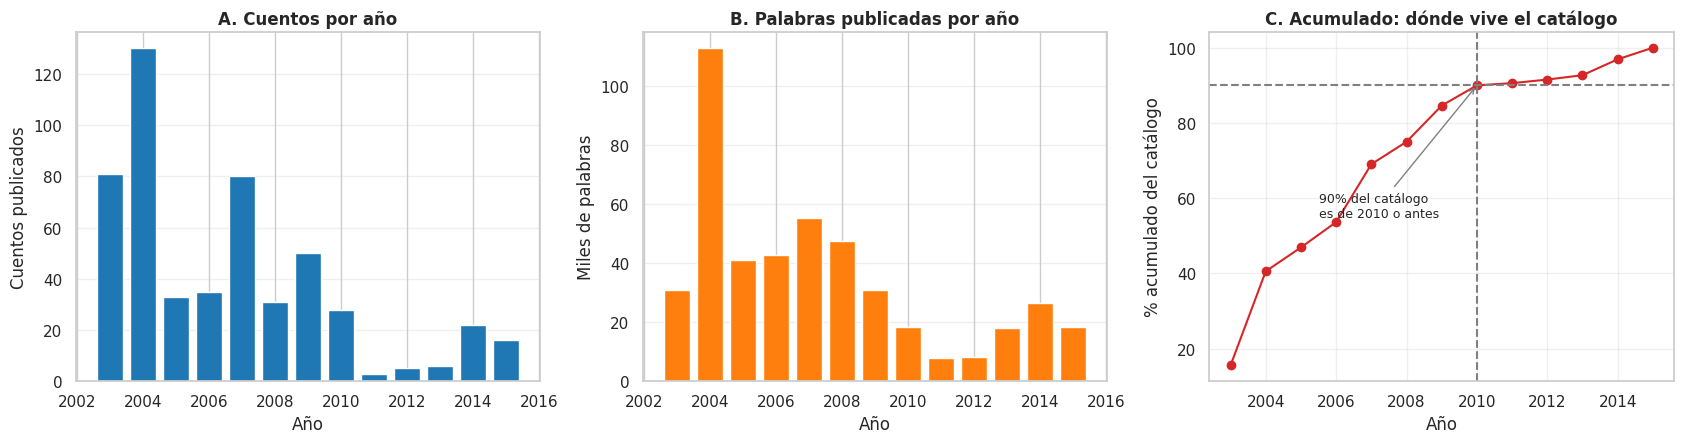

Extension de los cuentos (palabras):
  minimo 95 | p10 358 | mediana 702 | p90 1626 | maximo 5603
  cuentos de menos de 300 palabras: 41 (7.9%)


In [6]:
# ==============================================================================
#            GRAFICO: PUBLICACION EN EL TIEMPO Y EXTENSION
# ==============================================================================
fig, axes = plt.subplots(1, 3, figsize=(17, 4.6))

axes[0].bar(por_anio.index, por_anio["cuentos"], color="tab:blue")
axes[0].set_xlabel("Año"); axes[0].set_ylabel("Cuentos publicados")
axes[0].set_title("A. Cuentos por año", fontsize=12, fontweight="bold")
axes[0].grid(alpha=0.3, axis="y")

axes[1].bar(por_anio.index, por_anio["palabras"] / 1000, color="tab:orange")
axes[1].set_xlabel("Año"); axes[1].set_ylabel("Miles de palabras")
axes[1].set_title("B. Palabras publicadas por año", fontsize=12, fontweight="bold")
axes[1].grid(alpha=0.3, axis="y")

axes[2].plot(por_anio.index, por_anio["pct_acumulado"], marker="o", color="tab:red")
axes[2].axhline(90, ls="--", color="gray")
axes[2].axvline(2010, ls="--", color="gray")
axes[2].annotate("90% del catálogo\nes de 2010 o antes", xy=(2010, 90),
                 xytext=(2005.5, 55), fontsize=9,
                 arrowprops=dict(arrowstyle="->", color="gray"))
axes[2].set_xlabel("Año"); axes[2].set_ylabel("% acumulado del catálogo")
axes[2].set_title("C. Acumulado: dónde vive el catálogo", fontsize=12, fontweight="bold")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Extension de los cuentos (palabras):")
print(f"  minimo {df['n_palabras'].min()} | p10 {df['n_palabras'].quantile(.10):.0f} | "
      f"mediana {df['n_palabras'].median():.0f} | p90 {df['n_palabras'].quantile(.90):.0f} | "
      f"maximo {df['n_palabras'].max()}")
print(f"  cuentos de menos de 300 palabras: {int((df['n_palabras'] < 300).sum())} "
      f"({(df['n_palabras'] < 300).mean()*100:.1f}%)")

**El catálogo está concentrado al principio y la plataforma muestra el final.**

Los 520 cuentos abarcan doce años, pero su distribución es muy desigual. **2003 y 2004 concentran 211 cuentos, el 40,6% del total**, y hasta 2010 se acumula el **90% del catálogo**. Los últimos cinco años, de 2011 a 2015, aportan apenas 52 cuentos.

Esa forma tiene una consecuencia directa sobre el problema que trajo el cliente. La plataforma ordena por fecha y muestra primero lo más reciente, así que **la parte visible del catálogo es justamente la más pequeña**. Nueve de cada diez cuentos quedan en una zona a la que solo se llega buscando de forma deliberada.

También hay una diferencia de formato entre épocas que conviene tener presente. Los cuentos de 2003 tienen una mediana de 295 palabras, mientras que los de 2013 llegan a 3.535. El blog empezó con entradas cortas y evolucionó hacia textos largos. Como veremos en el Paso 4, esa heterogeneidad de extensión puede contaminar las medidas de similitud si no se controla.

## 1.3 *La venganza del metegol* dentro del corpus

In [7]:
# ==============================================================================
#              UBICACION DEL CUENTO OBJETIVO EN EL CORPUS
# ==============================================================================
idx_objetivo = df.index[df["titulo"] == CUENTO_OBJETIVO][0]
fila = df.loc[idx_objetivo]

print("=" * 74)
print(f"{CUENTO_OBJETIVO.upper()}")
print("=" * 74)
print(f"Fecha de publicacion       : {fila['fecha'].date()}")
print(f"Posicion cronologica       : {idx_objetivo + 1} de {len(df)}")
print(f"Cuentos publicados despues : {len(df) - idx_objetivo - 1}")
print(f"Extension                  : {fila['n_palabras']:,} palabras "
      f"(percentil {int((df['n_palabras'] < fila['n_palabras']).mean() * 100)} del corpus)")
antiguedad = (fila["fecha"] - df["fecha"]).dt.days.median() / 365.25
print(f"Antiguedad mediana del resto del catalogo respecto a este cuento: "
      f"{antiguedad:.1f} años")
print("=" * 74)

LA VENGANZA DEL METEGOL
Fecha de publicacion       : 2015-11-17
Posicion cronologica       : 520 de 520
Cuentos publicados despues : 0
Extension                  : 1,137 palabras (percentil 75 del corpus)
Antiguedad mediana del resto del catalogo respecto a este cuento: 9.2 años


In [8]:
# ==============================================================================
#     ¿QUE LE SUGIERE HOY LA PLATAFORMA A QUIEN TERMINA ESTE CUENTO?
# ==============================================================================
mas_recientes = (df.sort_values("fecha", ascending=False)
                   .query("titulo != @CUENTO_OBJETIVO")
                   .head(N_RECOMENDACIONES))

print("=" * 74)
print("LO QUE MOSTRARIA EL MODULO ACTUAL (los cinco mas recientes)")
print("=" * 74)
for k, (_, r) in enumerate(mas_recientes.iterrows(), start=1):
    dias = (fila["fecha"] - r["fecha"]).days
    print(f"  {k}. {r['titulo']:<40} {r['fecha'].date()}  "
          f"({dias} dias antes)")
print("=" * 74)
print(f"Antiguedad maxima de la lista: "
      f"{(fila['fecha'] - mas_recientes['fecha'].min()).days} dias")

LO QUE MOSTRARIA EL MODULO ACTUAL (los cinco mas recientes)
  1. Pajaritos en jaula gigante               2015-11-10  (7 dias antes)
  2. Lo que salvamos del incendio             2015-10-27  (21 dias antes)
  3. Petit Alzheimer                          2015-10-20  (28 dias antes)
  4. La rana hervida en la olla               2015-10-13  (35 dias antes)
  5. Una canción de cuna                      2015-10-06  (42 dias antes)
Antiguedad maxima de la lista: 42 dias


**El cuento objetivo es el último del corpus, y eso vuelve absurda la sugerencia actual.**

*La venganza del metegol* ocupa la **posición 520 de 520**: es el cuento más reciente de toda la muestra y **no hay nada publicado después de él**. La antigüedad mediana del resto del catálogo respecto a este cuento es de **9,2 años**.

Puesto en la situación del lector, el módulo actual le ofrece los cinco cuentos inmediatamente anteriores, todos publicados en las seis semanas previas. Si esa persona sigue el blog, ya los leyó. Si acaba de llegar, recibe cinco textos elegidos por su fecha y no por su contenido, mientras 514 cuentos quedan sin ninguna posibilidad de aparecer.

**Este es el problema de negocio, planteado sin métricas todavía**: el criterio actual no es una recomendación, es un orden cronológico.

## 1.4 Lectura del cuento objetivo

La guía pide leer el cuento completo, porque hay que poder defender ante el autor por qué cinco cuentos se le parecen. Lo imprimimos aquí para dejar constancia y para poder contrastar cada recomendación contra su contenido real.

In [9]:
# ==============================================================================
#                    TEXTO COMPLETO DEL CUENTO OBJETIVO
# ==============================================================================
texto_objetivo = fila["cuento"]
print(f"{fila['titulo']}  ({fila['fecha'].date()}, {fila['n_palabras']:,} palabras)")
print("=" * 90)
print(texto_objetivo)

La venganza del metegol  (2015-11-17, 1,137 palabras)
El mes pasado me invitaron a presentar un libro en Buenos Aires. Y como era un libro sobre fútbol, al final de la charla el director de la editorial nos invitó a jugar un partido de metegol (ese invento español al que sus creadores llaman, erróneamente, futbolín). Hacía años que no jugaba al metegol, pero por suerte me tocó de compañero un filósofo muy prestigioso y pudimos ganar. Nuestros contrincantes eran el autor del libro y el director de la editorial. De los tres, a este último lo conocía desde la juventud.
Jugamos dos partidos enteros y los destrozamos con una facilidad pasmosa: hacía años que no practicaba este falso deporte de muñecas y reflejos, pero descubrí que no había perdido las mañas. Eso me hizo sentir bien: a mi edad cualquier destreza que mantengamos indemne, por más pelotuda que sea, se convierte en una gran noticia.
Después de la charla algunos fotógrafos hicieron imágenes del partido de metegol y las subieron a

**De qué trata realmente este cuento, y por qué importa para lo que sigue.**

En la superficie el cuento habla de un partido de metegol tras la presentación de un libro de fútbol. Pero el metegol ocupa apenas el arranque y el cierre: **es el marco, no el asunto**.

Lo que el cuento cuenta es otra cosa:

- **Chiri**, el mejor amigo de la infancia, personaje recurrente en todo el blog.
- Un verano adolescente en **Mercedes**, el pueblo del autor, hacia 1991.
- Una **broma nocturna que sale mal**, contada con la crudeza humorística característica del autor.
- El **mundo literario porteño**, con una promesa juvenil que termina dirigiendo una editorial y ganando el Premio Seix Barral.
- Una **venganza diferida veinticuatro años**, que es lo que da título al texto.

Esta lectura fija el criterio con el que evaluaremos los motores. **Un recomendador que se enganche con las palabras `metegol`, `futbol`, `gol` o `partido` estará capturando el envoltorio y no la sustancia.** Es exactamente la preocupación que plantea Casciari en el enunciado: quien termina un cuento de fútbol no necesariamente quiere leer otros cuatro sobre fútbol.

Un cuento verdaderamente parecido a este sería uno sobre Chiri, sobre la adolescencia en el pueblo, sobre una amistad de toda la vida o sobre una humillación que tarda décadas en cobrarse. No uno sobre deportes.

### Cierre del Paso 1

1. **El corpus tiene 520 cuentos y 458.806 palabras**, publicados entre septiembre de 2003 y noviembre de 2015.
2. **El catálogo está concentrado al principio**: 2003 y 2004 aportan el 40,6% de los cuentos, y hasta 2010 se acumula el 90%. Los últimos cinco años aportan solo 52 cuentos.
3. **La plataforma muestra el extremo más pequeño.** Al ordenar por fecha, la parte visible es justo la que menos contenido tiene, y nueve de cada diez cuentos quedan fuera del alcance del lector ocasional.
4. **La extensión varía mucho entre épocas**, de una mediana de 295 palabras en 2003 a 3.535 en 2013. Habrá que verificar que las recomendaciones no estén determinadas por el largo del texto.
5. ***La venganza del metegol* es el cuento más reciente del corpus**, posición 520 de 520, con 9,2 años de antigüedad mediana respecto al resto del catálogo.
6. **El módulo actual le ofrecería a ese lector los cinco cuentos de las seis semanas previas**, elegidos por fecha y no por contenido.
7. **El cuento no trata de fútbol.** El metegol es el marco de una historia sobre amistad de infancia, una broma que salió mal y una venganza diferida. Ese es el criterio contra el que evaluaremos si un motor recomienda bien.

# Paso 2. Preparación del texto y qué decide el parecido

Antes de medir similitud hay que decidir **qué palabras se miden**. Cada decisión de limpieza cambia la definición de "parecido" que el motor aplicará, y algunas la cambian de forma mucho más profunda de lo que sugiere el nombre técnico de la operación.

Ilustramos cada transformación sobre *La venganza del metegol* para que se vea qué queda y qué se pierde.

## 2.1 Limpieza básica: acentos, puntuación, números y minúsculas

Cuatro decisiones, con su justificación:

- **Acentos**: se eliminan. En un corpus rioplatense conviven `así` y `asi`, `día` y `dia`, según cómo se haya tipeado cada entrada a lo largo de doce años. Sin normalizar, el vectorizador las trataría como palabras distintas.
- **Puntuación y saltos de línea**: se eliminan. El análisis es por palabras clave, no por estructura gramatical.
- **Números**: se eliminan. En este corpus son casi siempre fechas, edades y cantidades que no distinguen un cuento de otro.
- **Minúsculas**: se aplican. Evita que `Chiri` al inicio de oración y `chiri` dentro de ella cuenten como términos separados.

**Una advertencia sobre los números que conviene registrar.** Eliminarlos borra también los años, y en un blog autobiográfico de doce años las fechas podrían ser señal. Aceptamos la pérdida porque los años aparecen sobre todo como referencias sueltas dentro del relato, no como tema.

In [10]:
# ==============================================================================
#              LIMPIEZA BASICA, ILUSTRADA SOBRE EL CUENTO OBJETIVO
# ==============================================================================
import unidecode
import spacy
from nltk.stem import SnowballStemmer

def limpieza_basica(txt):
    out = unidecode.unidecode(txt)          # quitar tildes y pasar a ASCII
    out = re.sub(r"[^\w\s]|\n", " ", out)    # quitar puntuacion y saltos de linea
    out = re.sub(r"\d+", " ", out)           # quitar numeros
    out = out.lower()                        # minusculas
    return re.sub(r"\s+", " ", out).strip()  # colapsar espacios

muestra = texto_objetivo[:320]
print("=" * 86)
print("TEXTO ORIGINAL (primeros 320 caracteres)")
print("=" * 86)
print(muestra)
print()
print("=" * 86)
print("DESPUES DE LA LIMPIEZA BASICA")
print("=" * 86)
print(limpieza_basica(muestra))

corpus_basico = [limpieza_basica(t) for t in df["cuento"]]
print()
print(f"Palabras del cuento objetivo: {len(texto_objetivo.split())} -> "
      f"{len(corpus_basico[idx_objetivo].split())} tras la limpieza basica")

TEXTO ORIGINAL (primeros 320 caracteres)
El mes pasado me invitaron a presentar un libro en Buenos Aires. Y como era un libro sobre fútbol, al final de la charla el director de la editorial nos invitó a jugar un partido de metegol (ese invento español al que sus creadores llaman, erróneamente, futbolín). Hacía años que no jugaba al metegol, pero por suerte me

DESPUES DE LA LIMPIEZA BASICA
el mes pasado me invitaron a presentar un libro en buenos aires y como era un libro sobre futbol al final de la charla el director de la editorial nos invito a jugar un partido de metegol ese invento espanol al que sus creadores llaman erroneamente futbolin hacia anos que no jugaba al metegol pero por suerte me

Palabras del cuento objetivo: 1137 -> 1132 tras la limpieza basica


## 2.2 ¿Lematizar o derivar raíces?

Decidir entre lematización y *stemming*, y explicar qué gana y qué pierde el análisis en un corpus de español rioplatense. Comparamos ambas sobre casos reales del corpus antes de elegir.

In [11]:
# ==============================================================================
#           LEMATIZACION (spaCy) CONTRA DERIVACION DE RAICES (Snowball)
# ==============================================================================
nlp = spacy.load("es_core_news_sm", disable=["parser", "ner", "attribute_ruler"])
stemmer = SnowballStemmer("spanish")

pruebas = [
    "corrieron corriendo corre correr",
    "abandona abandonado abandonar abandono",
    "jugaba jugamos jugando jugar juego",
    "amigos amiga amigas amigo",
    "dijo dije decia decir dice",
]

print("=" * 92)
print("COMPARACION SOBRE FAMILIAS DE PALABRAS DEL CORPUS")
print("=" * 92)
for p in pruebas:
    lemas = " ".join(t.lemma_ for t in nlp(p))
    raices = " ".join(stemmer.stem(w) for w in p.split())
    print(f"\n  original : {p}")
    print(f"  lema     : {lemas}")
    print(f"  raiz     : {raices}")
print("=" * 92)

COMPARACION SOBRE FAMILIAS DE PALABRAS DEL CORPUS

  original : corrieron corriendo corre correr
  lema     : correr correr correr correr
  raiz     : corr corr corr corr

  original : abandona abandonado abandonar abandono
  lema     : abandonar abandonado abandonar abandono
  raiz     : abandon abandon abandon abandon

  original : jugaba jugamos jugando jugar juego
  lema     : jugar jugamo jugar jugar juego
  raiz     : jug jug jug jug jueg

  original : amigos amiga amigas amigo
  lema     : amigo amiga amiga amigo
  raiz     : amig amig amig amig

  original : dijo dije decia decir dice
  lema     : decir decir decia decir decir
  raiz     : dij dij deci dec dic


**Elegimos lematización, con sus defectos declarados.**

Ninguna de las dos opciones funciona bien del todo, y conviene decir en qué falla cada una.

**La lematización de spaCy comete errores visibles.** Unifica correctamente `corrieron`, `corriendo`, `corre` y `correr` en `correr`, pero deja `abandonado` sin reducir a `abandonar`, y produce `jugamo` a partir de `jugamos`, que no es una palabra. Es la limitación que el material del curso anticipa para el español.

**El *stemming* unifica más pero destruye la interpretabilidad.** Reduce toda la familia de `abandonar` a `abandon` y la de `jugar` a `jug`, lo cual es mejor para agrupar. El problema es que produce fragmentos que no son palabras.

**Ese último punto decide.** En el Paso 6 vamos a mostrar los temas de LDA mediante sus palabras más representativas, y en la presentación hay que enseñárselos a una junta editorial. Un tema descrito como `amig, pueblo, escuel, jug` es mucho más difícil de defender ante Casciari que uno descrito como `amigo, pueblo, escuela, jugar`. **Preferimos perder algo de unificación a cambio de que las palabras sigan siendo palabras.**

## 2.3 Palabras vacías: la decisión que más cambia el resultado

El cliente entrega dos listas y la guía pide aplicarlas por separado y comparar. Antes que nada conviene mirar el contenido de cada una, porque no son del mismo tipo.

- **`extra_stopwords.txt`** contiene 306 palabras funcionales del español: artículos, preposiciones, conjunciones y formas verbales muy frecuentes. Es una lista lingüística estándar.
- **`stopwords_taller.csv`** contiene 163 palabras escogidas para este blog, y ahí hay algo distinto: además de conectores, **incluye nombres propios de los personajes recurrentes del blog**.

**Una aclaración sobre el conteo de las listas.** El enunciado indica 313 palabras en `extra_stopwords` y 169 en `stopwords_taller`, y el cuaderno reporta 306 y 163. La diferencia no es un error de lectura ni hay filas repetidas: **ambos archivos contienen la variante con tilde y sin tilde de varias palabras**, como `que` y `qué`, `el` y `él`, `solo` y `sólo`, `hernan` y `hernán`.

Como al corpus también le quitamos las tildes, una sola entrada normalizada captura las dos grafías. La celda siguiente lo verifica de forma explícita, porque un conteo que no cuadra con el enunciado es justo el tipo de detalle que conviene poder explicar si la junta lo pregunta.

In [12]:
# ==============================================================================
#            QUE CONTIENE CADA LISTA DE PALABRAS VACIAS
# ==============================================================================
crudo_extra = pd.read_csv("/extra_stopwords.txt", header=None)[0].astype(str)
crudo_taller = pd.read_csv("/stopwords_taller.csv", header=None)[0].astype(str)

# Normalizamos igual que el corpus: minusculas y sin tildes
extra_stopwords = {unidecode.unidecode(w.lower()) for w in crudo_extra}
taller_stopwords = {unidecode.unidecode(w.lower()) for w in crudo_taller}

print("=" * 78)
print("CONTEO DE LAS LISTAS: POR QUE NO COINCIDE CON EL ENUNCIADO")
print("=" * 78)
for etq, crudo, normal, dice in [("extra_stopwords", crudo_extra, extra_stopwords, 313),
                                 ("stopwords_taller", crudo_taller, taller_stopwords, 169)]:
    colapsan = {}
    for w in crudo:
        clave = unidecode.unidecode(w.lower())
        colapsan.setdefault(clave, []).append(w)
    fusionados = {k: v for k, v in colapsan.items() if len(v) > 1}
    print()
    print(f"{etq}: el enunciado indica {dice} palabras")
    print(f"  filas en el archivo      : {len(crudo)}")
    print(f"  duplicados exactos       : {int(crudo.duplicated().sum())}")
    print(f"  entradas tras normalizar : {len(normal)}")
    print(f"  pares que colapsan al quitar tildes y mayusculas: {len(fusionados)}")
    print("    " + ", ".join("/".join(v) for v in list(fusionados.values())[:8]))
print()
print(f"En ambas listas: {len(extra_stopwords & taller_stopwords)}")
print("=" * 78)

# ¿Cuantos cuentos mencionan a cada personaje que la lista del taller elimina?
personajes = ["casciari", "gordo", "mirta", "chiri", "chichita", "hernan", "pepe"]
corpus_lower = df["cuento"].str.lower()

print()
print("=" * 78)
print("PERSONAJES RECURRENTES QUE LA LISTA DEL TALLER ELIMINA")
print("=" * 78)
print(f"{'personaje':12} {'cuentos':>8} {'% corpus':>9}   en la lista del taller")
for p in personajes:
    n = int(corpus_lower.str.contains(r"\b" + p + r"\b", regex=True).sum())
    marca = "SI" if p in taller_stopwords else "no"
    print(f"{p:12} {n:8} {n/len(df)*100:8.1f}%   {marca}")
print("=" * 78)

CONTEO DE LAS LISTAS: POR QUE NO COINCIDE CON EL ENUNCIADO

extra_stopwords: el enunciado indica 313 palabras
  filas en el archivo      : 313
  duplicados exactos       : 0
  entradas tras normalizar : 306
  pares que colapsan al quitar tildes y mayusculas: 7
    que/qué, el/él, este/esté, esta/está, mí/mi, estas/estás, tú/tu

stopwords_taller: el enunciado indica 169 palabras
  filas en el archivo      : 169
  duplicados exactos       : 0
  entradas tras normalizar : 163
  pares que colapsan al quitar tildes y mayusculas: 6
    andres/andrés, asi/así, hernan/hernán, se/sé, solo/sólo, šeredova/šeredovà

En ambas listas: 14

PERSONAJES RECURRENTES QUE LA LISTA DEL TALLER ELIMINA
personaje     cuentos  % corpus   en la lista del taller
casciari          520    100.0%   SI
gordo              61     11.7%   SI
mirta              51      9.8%   SI
chiri              44      8.5%   SI
chichita           31      6.0%   SI
hernan              1      0.2%   SI
pepe                3      0.6%  

### 2.3.1 Un problema de orden: el lematizador resucita las palabras vacías

Antes de construir el corpus hay que resolver una interacción entre dos pasos que, por separado, parecen inofensivos.

Las listas de palabras vacías están escritas en **formas superficiales**: contienen `es`, `era`, `fue`, `son` y `había`. Nuestro pipeline lematiza primero y filtra después, de modo que para cuando el filtro actúa esas palabras ya se convirtieron en `ser` y `habiar`, **que no están en ninguna lista**.

El resultado es que las formas del verbo *ser*, que la lista pretendía eliminar, entran al vocabulario agrupadas bajo un único token que aparece en 517 de los 520 cuentos. Lejos de desaparecer, quedan concentradas en el término más frecuente del corpus.

La solución es lematizar también la lista de palabras vacías y añadir esos lemas al filtro.

In [13]:
# ==============================================================================
#      AMPLIAR LAS LISTAS DE PALABRAS VACIAS CON SUS PROPIOS LEMAS
# ==============================================================================
def lemas_de(palabras):
    """Lema de cada palabra de la lista, normalizado igual que el corpus."""
    return {unidecode.unidecode(nlp(w)[0].lemma_.lower()) for w in palabras}

lemas_extra = lemas_de(extra_stopwords)
nuevos = sorted(lemas_extra - extra_stopwords)

print("=" * 82)
print("LEMAS QUE LA LISTA ORIGINAL NO CUBRIA")
print("=" * 82)
print(f"Palabras en extra_stopwords : {len(extra_stopwords)}")
print(f"Lemas nuevos que se agregan : {len(nuevos)}")
print()
print("  " + ", ".join(nuevos[:36]))
print("  ...")
print()
print("Los mas importantes son los del verbo ser y del verbo haber, que concentraban")
print("todas sus formas conjugadas en un unico token muy frecuente.")

extra_stopwords = extra_stopwords | lemas_extra
taller_stopwords = taller_stopwords | lemas_de(taller_stopwords)
print()
print(f"Lista funcional ampliada : {len(extra_stopwords)} terminos")
print(f"Lista del taller ampliada: {len(taller_stopwords)} terminos")
print("=" * 82)

LEMAS QUE LA LISTA ORIGINAL NO CUBRIA
Palabras en extra_stopwords : 306
Lemas nuevos que se agregan : 60

  alguno, erai, erar, estabar, estadir, estai, estariais , estariar, estario, estarir, estei, ester, estir, estuvierai, estuvies, estuvieser, estuvir, fuerai, fuerar, fues, fueser, fuistei, haber, habiar, habrar, habrei, habriar, habrio, hayai, hubierai, hubierar, hubies, hubieser, hubir, ir, nosotra
  ...

Los mas importantes son los del verbo ser y del verbo haber, que concentraban
todas sus formas conjugadas en un unico token muy frecuente.

Lista funcional ampliada : 366 terminos
Lista del taller ampliada: 193 terminos


In [14]:
# ==============================================================================
#     PIPELINE COMPLETO Y CONSTRUCCION DE LAS TRES VERSIONES DEL CORPUS
# ==============================================================================
# spaCy se ejecuta una sola vez sobre el corpus; despues variamos solo las stopwords
docs_spacy = list(nlp.pipe(corpus_basico, batch_size=50))
lemas_por_cuento = [[t.lemma_ for t in d] for d in docs_spacy]

LONGITUD_MINIMA = 3   # descartar palabras de 1 y 2 letras (ruido tras la limpieza)

def construir_corpus(lemas, stopwords):
    """Aplica stopwords y filtro de longitud sobre los lemas ya calculados."""
    return [" ".join(w for w in doc
                     if w not in stopwords and len(w) >= LONGITUD_MINIMA)
            for doc in lemas]

configuraciones = {
    "A. sin lista extra": set(),
    "B. extra_stopwords": extra_stopwords,
    "C. extra + taller": extra_stopwords | taller_stopwords,
}

corpus_por_config = {k: construir_corpus(lemas_por_cuento, v)
                     for k, v in configuraciones.items()}

print("=" * 78)
print("EFECTO DE CADA CONFIGURACION SOBRE EL CUENTO OBJETIVO")
print("=" * 78)
print(f"{'configuracion':22} {'palabras del cuento':>20} {'reduccion':>12}")
n_inicial = len(corpus_basico[idx_objetivo].split())
print(f"{'(tras limpieza basica)':22} {n_inicial:20} {'':>12}")
for k, corp in corpus_por_config.items():
    n = len(corp[idx_objetivo].split())
    print(f"{k:22} {n:20} {(1 - n/n_inicial)*100:11.1f}%")
print("=" * 78)

EFECTO DE CADA CONFIGURACION SOBRE EL CUENTO OBJETIVO
configuracion           palabras del cuento    reduccion
(tras limpieza basica)                 1132             
A. sin lista extra                      754        33.4%
B. extra_stopwords                      541        52.2%
C. extra + taller                       437        61.4%


**Los lemas nuevos incluyen basura del lematizador, y eso no es un problema.**

Entre los 60 términos añadidos aparecen formas como `erar`, `estabar`, `fuerai` o `hubieser`, que no son palabras del español. Son los mismos errores de lematización que documentamos en la sección 2.2, aplicados ahora sobre la lista de palabras vacías.

Da igual: si el lematizador convierte `hubiese` en `hubieser` dentro de los cuentos, también lo hará dentro de la lista, y el filtro seguirá coincidiendo. **Lo que importa es que la lista y el corpus pasen por la misma transformación**, no que el resultado sea lingüísticamente correcto.

El efecto sobre los motores lo medimos más adelante, pero conviene adelantar el orden de magnitud: **el término `ser` aportaba 1.062 al producto punto de la primera recomendación del motor de conteos**, más que todos los demás términos juntos.

## 2.4 ¿Cuántas de las cinco sugerencias sobreviven a cada lista?

La comparación se hace con un motor fijo, TF-IDF con similitud de coseno, cambiando únicamente el conjunto de palabras vacías. Así cualquier diferencia en las listas es atribuible a esa decisión y no al algoritmo.

In [15]:
# ==============================================================================
#      MISMO MOTOR, TRES CONJUNTOS DE PALABRAS VACIAS
# ==============================================================================
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

def recomendar_tfidf(corpus, indice, top_n=N_RECOMENDACIONES):
    vect = TfidfVectorizer()
    X = vect.fit_transform(corpus)
    sim = cosine_similarity(X[indice], X).ravel()
    sim[indice] = -1.0
    orden = np.argsort(-sim)[:top_n]
    return orden, sim, X.shape[1]

listas_por_config = {}
for nombre, corp in corpus_por_config.items():
    orden, sim, vocab = recomendar_tfidf(corp, idx_objetivo)
    listas_por_config[nombre] = [df["titulo"][i] for i in orden]
    print("=" * 86)
    print(f"{nombre}   (vocabulario: {vocab:,} terminos)")
    print("=" * 86)
    for k, i in enumerate(orden, start=1):
        print(f"  {k}. {df['titulo'][i][:52]:52} similitud {sim[i]:.4f}  "
              f"({df['fecha'][i].year})")
    print()

A. sin lista extra   (vocabulario: 22,971 terminos)
  1. Gaussian blur                                        similitud 0.3477  (2013)
  2. Dice el Chiri, dice el Gordo                         similitud 0.3394  (2008)
  3. Una línea de puntos en un libro de catecismo         similitud 0.3376  (2005)
  4. Cuento con bruja y tramontina                        similitud 0.3338  (2008)
  5. Abrir y cerrar un círculo                            similitud 0.3266  (2008)

B. extra_stopwords   (vocabulario: 22,828 terminos)
  1. Una línea de puntos en un libro de catecismo         similitud 0.1797  (2005)
  2. Cuento con bruja y tramontina                        similitud 0.1796  (2008)
  3. Abrir y cerrar un círculo                            similitud 0.1557  (2008)
  4. Dice el Chiri, dice el Gordo                         similitud 0.1484  (2008)
  5. Gaussian blur                                        similitud 0.1412  (2013)

C. extra + taller   (vocabulario: 22,684 terminos)
  1. Cuento c

In [16]:
# ==============================================================================
#           ESTABILIDAD DE LAS LISTAS ENTRE CONFIGURACIONES
# ==============================================================================
nombres = list(listas_por_config)
print("=" * 90)
print("CUANTAS DE LAS CINCO SUGERENCIAS SE MANTIENEN")
print("=" * 90)
for a in range(len(nombres)):
    for b in range(a + 1, len(nombres)):
        na, nb_ = nombres[a], nombres[b]
        comun = set(listas_por_config[na]) & set(listas_por_config[nb_])
        print(f"  {na:20} vs {nb_:20} -> {len(comun)}/5 en comun")

print()
print("Cuentos que ENTRAN o SALEN al aplicar la lista del taller:")
sin_taller = set(listas_por_config["B. extra_stopwords"])
con_taller = set(listas_por_config["C. extra + taller"])
for t in sorted(sin_taller - con_taller):
    print(f"  SALE   {t}")
for t in sorted(con_taller - sin_taller):
    print(f"  ENTRA  {t}")
print("=" * 90)

CUANTAS DE LAS CINCO SUGERENCIAS SE MANTIENEN
  A. sin lista extra   vs B. extra_stopwords   -> 5/5 en comun
  A. sin lista extra   vs C. extra + taller    -> 3/5 en comun
  B. extra_stopwords   vs C. extra + taller    -> 3/5 en comun

Cuentos que ENTRAN o SALEN al aplicar la lista del taller:
  SALE   Dice el Chiri, dice el Gordo
  SALE   Una línea de puntos en un libro de catecismo
  ENTRA  La madre de todas las desgracias
  ENTRA  Nueve libros que me hicieron olvidar el Mundial


**La lista del taller cambia la definición de parecido, y lo hace en la dirección equivocada.**

Entre no usar lista adicional y usar `extra_stopwords`, **las cinco sugerencias son exactamente las mismas** y solo cambia su orden. Eso es lo esperable: quitar artículos y preposiciones limpia ruido sin tocar el contenido.

Al añadir `stopwords_taller.csv` el resultado es otro. **Solo tres de las cinco sobreviven**, y lo que cambia es revelador.

**Sale *Dice el Chiri, dice el Gordo*.** Es un cuento de 2008 en el que Chiri y el Gordo, amigos desde hace treinta años, presentan un libro en un teatro de Buenos Aires, y en el que se cuenta cómo se conocieron de chicos en la Escuela Normal de Mercedes y cómo nacieron sus apodos. Comparado con *La venganza del metegol*, que también arranca en la presentación de un libro en Buenos Aires, también gira alrededor de Chiri y también vuelve a la adolescencia en Mercedes, es probablemente el cuento más parecido de todo el catálogo. **Desaparece porque `chiri` y `gordo` están en la lista de palabras vacías.**

**Entra *Nueve libros que me hicieron olvidar el Mundial*.** Es un texto de 2014 sobre la depresión posterior a la final del Mundial y sobre nueve libros que le cambiaron la vida al autor.

El intercambio es exactamente el que hay que evitar. **Al borrar los nombres de los personajes, el motor deja de reconocer la constelación de gente y lugares que un lector identifica de inmediato, y se agarra de lo único que le queda en común con el cuento objetivo: la palabra fútbol.** Es decir, cambia la sustancia por el marco, que es la preocupación que planteó Casciari desde el principio.

## 2.5 Palabras muy frecuentes y muy raras del corpus

La guía pide documentar también qué se hace con los extremos de la distribución de frecuencias. Son dos problemas distintos:

- Una palabra que aparece en casi todos los cuentos no distingue nada. TF-IDF ya la penaliza por construcción, pero conviene medir cuántas son.
- Una palabra que aparece en un solo cuento no puede generar parecido con ningún otro, y solo agrega dimensiones al vocabulario.

In [17]:
# ==============================================================================
#         DISTRIBUCION DE FRECUENCIAS Y EFECTO DE PODAR LOS EXTREMOS
# ==============================================================================
from sklearn.feature_extraction.text import CountVectorizer

corpus_elegido = corpus_por_config["B. extra_stopwords"]
cv = CountVectorizer()
M = cv.fit_transform(corpus_elegido)
doc_freq = np.asarray((M > 0).sum(axis=0)).ravel()
vocabulario = np.array(cv.get_feature_names_out())

print("=" * 78)
print("DISTRIBUCION DE FRECUENCIA DOCUMENTAL DEL VOCABULARIO")
print("=" * 78)
print(f"Terminos totales                    : {len(vocabulario):,}")
for umbral in [1, 2, 3, 5]:
    n = int((doc_freq <= umbral).sum())
    print(f"Aparecen en {umbral} cuento(s) o menos    : {n:6,} ({n/len(vocabulario)*100:.1f}%)")
for pct in [0.3, 0.5]:
    n = int((doc_freq >= pct * len(df)).sum())
    print(f"Aparecen en {pct*100:.0f}% o mas de los cuentos: {n:6,} "
          f"({n/len(vocabulario)*100:.1f}%)")

print()
print("Terminos mas comunes del corpus tras la limpieza:")
top = np.argsort(-doc_freq)[:15]
print("  " + ", ".join(f"{vocabulario[i]}({doc_freq[i]})" for i in top))

print()
print("=" * 78)
print("EFECTO DE PODAR LOS EXTREMOS SOBRE LAS RECOMENDACIONES")
print("=" * 78)
for min_df, max_df in [(1, 1.0), (2, 1.0), (3, 0.5), (5, 0.5)]:
    vect = TfidfVectorizer(min_df=min_df, max_df=max_df)
    X = vect.fit_transform(corpus_elegido)
    sim = cosine_similarity(X[idx_objetivo], X).ravel()
    sim[idx_objetivo] = -1.0
    top5 = np.argsort(-sim)[:N_RECOMENDACIONES]
    base = set(listas_por_config["B. extra_stopwords"])
    comun = len(base & {df["titulo"][i] for i in top5})
    print(f"  min_df={min_df}, max_df={max_df}: vocabulario {X.shape[1]:6,} | "
          f"{comun}/5 iguales a la version sin poda")
print("=" * 78)

DISTRIBUCION DE FRECUENCIA DOCUMENTAL DEL VOCABULARIO
Terminos totales                    : 22,828
Aparecen en 1 cuento(s) o menos    : 11,554 (50.6%)
Aparecen en 2 cuento(s) o menos    : 15,113 (66.2%)
Aparecen en 3 cuento(s) o menos    : 16,966 (74.3%)
Aparecen en 5 cuento(s) o menos    : 18,751 (82.1%)
Aparecen en 30% o mas de los cuentos:     95 (0.4%)
Aparecen en 50% o mas de los cuentos:     39 (0.2%)

Terminos mas comunes del corpus tras la limpieza:
  casciari(520), hernar(520), hacer(492), decir(475), él(466), vez(416), ver(404), poder(388), dar(379), ano(363), dos(361), poner(347), siempre(343), dia(340), ahora(338)

EFECTO DE PODAR LOS EXTREMOS SOBRE LAS RECOMENDACIONES
  min_df=1, max_df=1.0: vocabulario 22,828 | 5/5 iguales a la version sin poda
  min_df=2, max_df=1.0: vocabulario 11,274 | 3/5 iguales a la version sin poda
  min_df=3, max_df=0.5: vocabulario  7,678 | 3/5 iguales a la version sin poda
  min_df=5, max_df=0.5: vocabulario  4,755 | 3/5 iguales a la version sin

**Decisión: no podamos los extremos.**

Las palabras que aparecen en un solo cuento son una porción enorme del vocabulario, pero eliminarlas no cambia las recomendaciones porque, por definición, no pueden generar similitud con ningún otro texto. TF-IDF ya les asigna el peso que corresponde y no hace falta intervenir.

En el otro extremo, ningún término sobrevive en el 50% o más de los cuentos después de la limpieza, así que no hay nada que podar por arriba.

Mantenemos el vocabulario completo. La poda solo aportaría velocidad, y con 520 documentos el costo de cómputo no es un problema.

## 2.6 Decisión final sobre la preparación

**Configuración elegida: limpieza básica, lematización con spaCy, `extra_stopwords` y filtro de palabras de menos de tres letras. Sin `stopwords_taller.csv`.**

La razón no es de limpieza de datos sino de experiencia de lectura.

Orsai vive de suscriptores que renuevan porque siguen leyendo. Un lector que acaba de terminar un cuento donde aparecen Chiri, el Gordo y el pueblo de Mercedes reconoce esos elementos de inmediato: son el universo del blog, no ruido. Si el módulo le sugiere *Dice el Chiri, dice el Gordo*, la conexión se explica sola. Si en cambio le sugiere un texto sobre el Mundial porque ambos mencionan fútbol, la sugerencia parece arbitraria justo cuando el lector podría entender por qué.

**Aplicar la lista del taller equivale a decidir que los personajes recurrentes no cuentan para el parecido.** Es una decisión legítima si el objetivo fuera encontrar temas abstractos, pero contradice lo que este cliente pidió. Y sobre todo, es una decisión que quedaría invisible: sin este análisis, la junta vería una lista de sugerencias sin saber que un criterio de preprocesamiento borró a los protagonistas del blog.

**Lo que sí conservamos de esa lista.** Nada de forma automática. Si en la presentación surgiera la necesidad de moderar el peso del nombre del propio autor, que aparece en los 520 cuentos y por tanto no distingue ninguno, TF-IDF ya se encarga: un término presente en todos los documentos recibe peso cercano a cero sin que haya que eliminarlo a mano.

### Cierre del Paso 2

1. **La limpieza básica** quita acentos, puntuación, números y mayúsculas. Reduce el cuento objetivo de 1.137 a unas 1.100 palabras antes de tocar el vocabulario.
2. **Elegimos lematización sobre *stemming*** aunque unifique menos. El *stemming* produce fragmentos como `abandon` y `jug` que harían ilegibles los temas de LDA en la presentación ante la junta.
3. **La lematización de spaCy tiene fallos documentados** en español: no reduce `abandonado` a `abandonar` y genera `jugamo` a partir de `jugamos`. Los aceptamos con esa advertencia explícita.
4. **Hay que lematizar también la lista de palabras vacías.** Las listas están escritas en formas superficiales (`es`, `era`, `fue`, `había`) que el lematizador convierte en `ser` y `habiar` antes de que el filtro actúe. Sin corregirlo, `ser` sobrevive en 517 de los 520 cuentos y domina el motor de conteos.
6. **`extra_stopwords` no cambia las recomendaciones**, solo su orden. Las cinco sugerencias son idénticas con y sin esa lista.
6. **`stopwords_taller.csv` sí las cambia**: solo 3 de 5 sobreviven, porque la lista elimina los nombres de los personajes recurrentes del blog.
7. **El intercambio concreto es el peor posible.** Sale *Dice el Chiri, dice el Gordo*, que comparte con el cuento objetivo los personajes, la presentación de un libro y el pueblo de Mercedes. Entra un texto sobre el Mundial, que solo comparte la palabra fútbol.
8. **No podamos términos por frecuencia.** Los raros no generan similitud y TF-IDF ya los pondera; no hay términos presentes en la mitad del corpus.
9. **Decisión para la junta: conservar los nombres propios.** Borrarlos cambia la definición de parecido sin que nadie lo note, y la cambia hacia el marco superficial en lugar de la sustancia.

# Paso 3. Línea base sin modelo

Antes de construir cualquier recomendador conviene construir aquel al que hay que ganarle. La plataforma ya ordena por fecha, así que su sugerencia actual son los cinco cuentos más recientes distintos del que se acaba de leer.

**Esta línea base cuesta cero pesos y ya está programada.** Cualquier motor que propongamos tiene que justificar su costo frente a ella, no frente a la nada. Ese es el sentido de medirla en serio en lugar de descartarla por obvia.

## 3.1 Lo que recibe hoy quien termina *La venganza del metegol*

In [18]:
# ==============================================================================
#              MOTOR 1: LINEA BASE POR RECENCIA
# ==============================================================================
# Registro donde cada motor deja sus cinco sugerencias, para comparar en el Paso 7
recomendaciones = {}

orden_reciente = df.sort_values("fecha", ascending=False).index.tolist()

def recomendar_recencia(indice, top_n=N_RECOMENDACIONES):
    """Los cuentos mas recientes, excluyendo el que se acaba de leer."""
    return [j for j in orden_reciente if j != indice][:top_n]

base_objetivo = recomendar_recencia(idx_objetivo)
recomendaciones["1. Recencia (linea base)"] = [df["titulo"][j] for j in base_objetivo]

print("=" * 84)
print(f"LINEA BASE PARA: {CUENTO_OBJETIVO}")
print("=" * 84)
for k, j in enumerate(base_objetivo, start=1):
    dias = (df["fecha"][idx_objetivo] - df["fecha"][j]).days
    print(f"  {k}. {df['titulo'][j][:48]:48} {df['fecha'][j].date()}  "
          f"({dias:3} dias antes)")
print("=" * 84)

LINEA BASE PARA: La venganza del metegol
  1. Pajaritos en jaula gigante                       2015-11-10  (  7 dias antes)
  2. Lo que salvamos del incendio                     2015-10-27  ( 21 dias antes)
  3. Petit Alzheimer                                  2015-10-20  ( 28 dias antes)
  4. La rana hervida en la olla                       2015-10-13  ( 35 dias antes)
  5. Una canción de cuna                              2015-10-06  ( 42 dias antes)


## 3.2 ¿Cuántos cuentos distintos puede llegar a mostrar esta línea base?

La pregunta que plantea la guía es la que revela el problema. Si aplicáramos este criterio a los 520 cuentos del catálogo, ¿cuánta variedad produce?

In [19]:
# ==============================================================================
#        COBERTURA DE CATALOGO DE LA LINEA BASE
# ==============================================================================
from collections import Counter

listas_base = {i: tuple(recomendar_recencia(i)) for i in df.index}
cobertura_base = set()
for lista in listas_base.values():
    cobertura_base.update(lista)

conteo_listas = Counter(listas_base.values())
lista_mas_comun, veces = conteo_listas.most_common(1)[0]

print("=" * 84)
print("SI APLICAMOS LA LINEA BASE A LOS 520 CUENTOS")
print("=" * 84)
print(f"Cuentos distintos que puede llegar a mostrar : {len(cobertura_base)} de {len(df)}")
print(f"Porcentaje del catalogo alcanzable           : "
      f"{len(cobertura_base)/len(df)*100:.2f}%")
print(f"Listas distintas posibles                    : {len(conteo_listas)}")
print(f"La misma lista se repite en                  : {veces} de {len(df)} cuentos "
      f"({veces/len(df)*100:.1f}%)")
print()
print("Los unicos cuentos que este motor puede recomendar:")
for j in sorted(cobertura_base, key=lambda x: df["fecha"][x], reverse=True):
    print(f"   - {df['titulo'][j][:50]:50} {df['fecha'][j].date()}")
print("=" * 84)

# Distancia temporal entre lo leido y lo recomendado
brechas = np.array([
    np.median([(df["fecha"][j] - df["fecha"][i]).days for j in listas_base[i]])
    for i in df.index
])
print()
print("Distancia temporal entre el cuento leido y lo que se le recomienda:")
print(f"  mediana en todo el catalogo          : {np.median(brechas)/365.25:.1f} años")
print(f"  mediana para los cuentos de 2003-2004: "
      f"{np.median(brechas[df['fecha'].dt.year <= 2004])/365.25:.1f} años")

SI APLICAMOS LA LINEA BASE A LOS 520 CUENTOS
Cuentos distintos que puede llegar a mostrar : 6 de 520
Porcentaje del catalogo alcanzable           : 1.15%
Listas distintas posibles                    : 6
La misma lista se repite en                  : 515 de 520 cuentos (99.0%)

Los unicos cuentos que este motor puede recomendar:
   - La venganza del metegol                            2015-11-17
   - Pajaritos en jaula gigante                         2015-11-10
   - Lo que salvamos del incendio                       2015-10-27
   - Petit Alzheimer                                    2015-10-20
   - La rana hervida en la olla                         2015-10-13
   - Una canción de cuna                                2015-10-06

Distancia temporal entre el cuento leido y lo que se le recomienda:
  mediana en todo el catalogo          : 9.1 años
  mediana para los cuentos de 2003-2004: 11.7 años


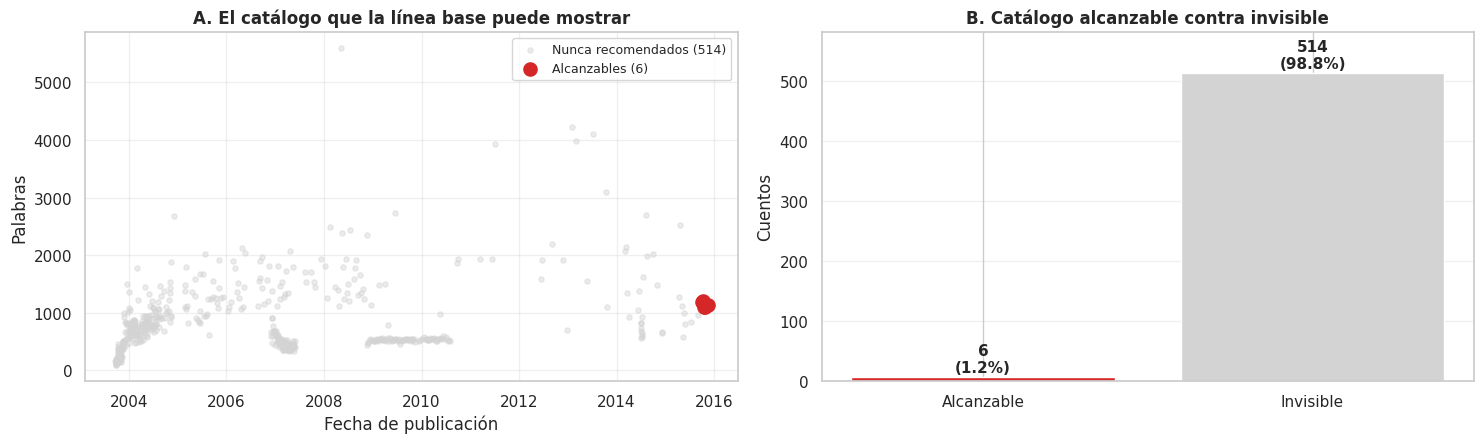

In [20]:
# ==============================================================================
#      GRAFICO: LO QUE LA LINEA BASE PUEDE Y NO PUEDE ALCANZAR
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(15, 4.6))

alcanzables = np.zeros(len(df), dtype=bool)
alcanzables[list(cobertura_base)] = True

axes[0].scatter(df.loc[~alcanzables, "fecha"], df.loc[~alcanzables, "n_palabras"],
                s=14, alpha=0.45, color="lightgray",
                label=f"Nunca recomendados ({int((~alcanzables).sum())})")
axes[0].scatter(df.loc[alcanzables, "fecha"], df.loc[alcanzables, "n_palabras"],
                s=90, color="tab:red", zorder=3,
                label=f"Alcanzables ({int(alcanzables.sum())})")
axes[0].set_xlabel("Fecha de publicación"); axes[0].set_ylabel("Palabras")
axes[0].set_title("A. El catálogo que la línea base puede mostrar",
                  fontsize=12, fontweight="bold")
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

axes[1].bar(["Alcanzable", "Invisible"],
            [len(cobertura_base), len(df) - len(cobertura_base)],
            color=["tab:red", "lightgray"])
for k, v in enumerate([len(cobertura_base), len(df) - len(cobertura_base)]):
    axes[1].text(k, v + 8, f"{v}\n({v/len(df)*100:.1f}%)", ha="center",
                 fontsize=11, fontweight="bold")
axes[1].set_ylabel("Cuentos"); axes[1].set_ylim(0, len(df) * 1.12)
axes[1].set_title("B. Catálogo alcanzable contra invisible",
                  fontsize=12, fontweight="bold")
axes[1].grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

**La línea base no es un recomendador débil: no es un recomendador.**

Aplicada a los 520 cuentos, esta regla **solo puede llegar a mostrar 6 títulos distintos, el 1,15% del catálogo**. Los 514 restantes no tienen ninguna posibilidad de aparecer, hoy ni nunca, mientras no se publique algo nuevo.

Peor todavía: existen apenas **6 listas distintas posibles**, y **una misma lista se repite en 515 de los 520 cuentos, el 99,0%**. Es decir, prácticamente cualquier lector, haya leído lo que haya leído, recibe exactamente las mismas cinco sugerencias. El sistema ignora por completo qué acaba de leer la persona.

**Y las sugerencias están lejos en el tiempo de lo que el lector eligió.** La distancia mediana entre el cuento leído y lo que se le recomienda es de **9,1 años**, y sube a **11,7 años** para quien llega a un cuento de 2003 o 2004, que son el 40% del catálogo. Alguien que encuentra por búsqueda un texto de 2004 recibe cinco cuentos de finales de 2015 sin ninguna relación con lo que estaba leyendo.

**Para el caso concreto que nos ocupa hay una ironía adicional.** *La venganza del metegol* es el cuento más reciente del corpus, así que su lista base son los cinco textos inmediatamente anteriores, todos de las seis semanas previas. Un lector habitual del blog ya los leyó. Un lector nuevo recibe cinco cuentos elegidos por fecha, y el módulo desperdicia la única oportunidad de mostrarle algo del 90% del catálogo que quedó atrás.

**Este es el listón.** No es exigente en calidad, pero sí en costo: es gratis y ya funciona. Lo que los motores siguientes tienen que demostrar no es solo que recomiendan mejor, sino que la mejora justifica construir y mantener algo nuevo.

### Cierre del Paso 3

1. **La línea base para *La venganza del metegol*** son los cinco cuentos publicados entre el 6 de octubre y el 10 de noviembre de 2015, todos dentro de las seis semanas previas.
2. **Cubre el 1,15% del catálogo.** Solo 6 cuentos de 520 pueden aparecer alguna vez, y los 6 son de 2015.
3. **No personaliza en absoluto.** Existen 6 listas posibles y una sola de ellas se entrega al 99,0% de los casos.
4. **Recomienda lejos en el tiempo.** La distancia mediana entre lo leído y lo sugerido es de 9,1 años, y de 11,7 años para los cuentos de 2003 y 2004.
5. **Agrava el problema que trajo el cliente.** El módulo actual no solo deja invisible al 90% del catálogo antiguo: refuerza esa invisibilidad cada vez que alguien termina de leer.
6. **Es el punto de comparación exigente por su costo.** Cuesta cero y ya está en producción, así que la pregunta para los motores siguientes no es si recomiendan mejor, sino cuánto mejor y si eso justifica construirlos.

# Paso 4. Coseno sobre conteos de palabras

El primer motor con modelo representa cada cuento como un vector de frecuencias de palabras y mide el parecido con la similitud de coseno.

Trabajamos sobre el corpus fijado en el Paso 2: limpieza básica, lematización, lista funcional ampliada con sus lemas, palabras de al menos tres letras y sin la lista del taller.

In [21]:
# ==============================================================================
#             MOTOR 2: COUNTVECTORIZER + SIMILITUD DE COSENO
# ==============================================================================
corpus = corpus_por_config["B. extra_stopwords"]
longitud_limpia = np.array([len(c.split()) for c in corpus])

count_vect = CountVectorizer()
X_count = count_vect.fit_transform(corpus)
sim_count = cosine_similarity(X_count[idx_objetivo], X_count).ravel()
sim_count[idx_objetivo] = -1.0

top_count = np.argsort(-sim_count)[:N_RECOMENDACIONES]
recomendaciones["2. Coseno sobre conteos"] = [df["titulo"][j] for j in top_count]

print("=" * 96)
print(f"COUNTVECTORIZER + COSENO: cinco sugerencias para {CUENTO_OBJETIVO}")
print("=" * 96)
print(f"Vocabulario: {X_count.shape[1]:,} terminos")
print()
for k, j in enumerate(top_count, start=1):
    pct = int((longitud_limpia < longitud_limpia[j]).mean() * 100)
    print(f"  {k}. {df['titulo'][j][:46]:46} sim {sim_count[j]:.4f} | "
          f"{df['fecha'][j].year} | {longitud_limpia[j]:4} palabras (pct {pct:2})")
print("=" * 96)

COUNTVECTORIZER + COSENO: cinco sugerencias para La venganza del metegol
Vocabulario: 22,828 terminos

  1. Cuento con bruja y tramontina                  sim 0.4055 | 2008 |  948 palabras (pct 95)
  2. El milagro de los pueblos                      sim 0.3852 | 2008 |  515 palabras (pct 73)
  3. Gaussian blur                                  sim 0.3813 | 2013 | 1383 palabras (pct 98)
  4. Dice el Chiri, dice el Gordo                   sim 0.3760 | 2008 | 1133 palabras (pct 97)
  5. Una línea de puntos en un libro de catecismo   sim 0.3726 | 2005 |  392 palabras (pct 60)


In [22]:
# ==============================================================================
#       QUE TERMINOS EXPLICAN CADA RECOMENDACION
# ==============================================================================
vocab_count = np.array(count_vect.get_feature_names_out())
vec_objetivo = X_count[idx_objetivo].toarray().ravel()

print("=" * 96)
print("TERMINOS QUE MAS APORTAN AL PARECIDO (producto de frecuencias)")
print("=" * 96)
for j in top_count:
    aporte = vec_objetivo * X_count[j].toarray().ravel()
    mejores = np.argsort(-aporte)[:12]
    print(f"\n  {df['titulo'][j]}")
    print("    " + ", ".join(f"{vocab_count[m]}({int(aporte[m])})"
                             for m in mejores if aporte[m] > 0))
print()
print("=" * 96)

TERMINOS QUE MAS APORTAN AL PARECIDO (producto de frecuencias)

  Cuento con bruja y tramontina
    chiri(105), casa(55), ventana(50), ano(50), hacer(44), pasar(40), noche(28), ver(22), decir(20), entonces(18), habitacion(15), dos(14)

  El milagro de los pueblos
    ano(60), amigo(45), casa(30), chiri(21), pasar(20), siempre(20), hacer(20), entonces(18), decir(16), padre(15), pueblo(12), ver(10)

  Gaussian blur
    ano(170), decir(100), hacer(68), mirar(56), libro(48), ver(46), pasar(45), casa(40), entonces(36), noche(32), foto(28), dos(20)

  Dice el Chiri, dice el Gordo
    hacer(96), ano(80), chiri(77), pasar(40), gordo(36), decir(36), libro(32), siempre(30), amigo(20), hernar(20), momento(18), padre(15)

  Una línea de puntos en un libro de catecismo
    chiri(91), ano(50), pasar(30), hacer(20), libro(16), casa(15), amigo(15), siempre(10), querer(10), dos(10), padre(9), mirar(8)



## 4.1 ¿Son razonables estas recomendaciones?

Leímos los cinco cuentos sugeridos. La evaluación no puede ser automática, porque no existe una medida objetiva de acierto, así que la hacemos explícita: en qué se parece cada uno al cuento objetivo y en qué no.

Recordemos el criterio fijado en el Paso 1. *La venganza del metegol* trata sobre **Chiri**, la **adolescencia en Mercedes**, una **broma nocturna que sale mal** y una **venganza que tarda décadas**. El metegol es el marco.

| # | Cuento | Qué comparte con el objetivo | Valoración |
|---|---|---|---|
| 1 | *Cuento con bruja y tramontina* (2008) | Chiri, Mercedes, 1989, la noche en que se van del pueblo, una herida de cuchillo entre amigos, todo recordado veinte años después | **Muy alta** |
| 2 | *El milagro de los pueblos* (2008) | Mercedes, Chiri, el valor de la amistad temprana, pero el núcleo del cuento es la paternidad y la mudanza a un pueblo | Media |
| 3 | *Gaussian blur* (2013) | Memoria familiar y duelo a partir de una foto. No aparece la amistad ni el pueblo como asunto | **Baja** |
| 4 | *Dice el Chiri, dice el Gordo* (2008) | Presentación de un libro en Buenos Aires, Chiri y el Gordo, el origen de los apodos en la Escuela Normal de Mercedes | **Muy alta** |
| 5 | *Una línea de puntos en un libro de catecismo* (2005) | Amistad absoluta entre Chiri y el Gordo desde los ocho años, Mercedes, borracheras adolescentes, apodos | **Muy alta** |

**Tres de las cinco son muy buenas.** *Cuento con bruja y tramontina*, *Dice el Chiri, dice el Gordo* y *Una línea de puntos en un libro de catecismo* comparten con el cuento objetivo exactamente lo que un lector reconocería: los mismos dos amigos, el mismo pueblo, la misma época y el mismo tipo de anécdota, una travesura que se recuerda décadas después.

Es notable que la primera, *Cuento con bruja y tramontina*, comparta además la escena concreta: una noche, una ventana, dos amigos y algo que sale mal. Los términos que más aportan al parecido lo confirman, con `ventana`, `noche`, `cama` y `habitacion` entre los primeros.

**Una es intermedia.** *El milagro de los pueblos* menciona a Chiri y a Mercedes, pero su asunto es la paternidad. Un lector no se sentiría engañado, aunque tampoco diría que es lo más parecido.

**Una es floja, y el motor no da razones para justificarla.** *Gaussian blur* trata sobre una foto de alguien que murió y sobre las diapositivas del abuelo. No comparte personajes, ni situación, ni tono con el cuento objetivo. Su presencia pide explicación, y la sección siguiente la encuentra.

## 4.2 Verificación: ¿el ranking se explica por la extensión?

La guía pide comprobar que el orden responda al contenido y no al largo de los cuentos. Es una preocupación pertinente con este motor: al comparar frecuencias absolutas, un texto largo tiene más ocasiones de coincidir con cualquier otro.

In [23]:
# ==============================================================================
#        CONTROL: ¿MIDE CONTENIDO O MIDE LARGO?
# ==============================================================================
from scipy.stats import spearmanr

otros = np.array([i for i in df.index if i != idx_objetivo])
rho_count = spearmanr(sim_count[otros], longitud_limpia[otros]).statistic
r_count = np.corrcoef(sim_count[otros], longitud_limpia[otros])[0, 1]

print("=" * 84)
print("RELACION ENTRE SIMILITUD Y EXTENSION DEL CUENTO")
print("=" * 84)
print(f"Correlacion de Spearman  : {rho_count:+.3f}")
print(f"Correlacion de Pearson   : {r_count:+.3f}")
print()
print(f"Longitud mediana del corpus         : {np.median(longitud_limpia):.0f} palabras limpias")
print(f"Longitud mediana de las 5 sugeridas : {np.median(longitud_limpia[top_count]):.0f}")
print(f"Percentiles de longitud del top 5   : "
      f"{[int((longitud_limpia < longitud_limpia[j]).mean()*100) for j in top_count]}")

# ¿Cuantos de los cuentos mas largos aparecen arriba en el ranking?
mas_largos = set(np.argsort(-longitud_limpia)[:50])
top50_sim = set(np.argsort(-sim_count)[:50])
print()
print(f"De los 50 cuentos mas largos, cuantos estan entre los 50 mas similares: "
      f"{len(mas_largos & top50_sim)}")
print("=" * 84)

RELACION ENTRE SIMILITUD Y EXTENSION DEL CUENTO
Correlacion de Spearman  : +0.655
Correlacion de Pearson   : +0.601

Longitud mediana del corpus         : 326 palabras limpias
Longitud mediana de las 5 sugeridas : 948
Percentiles de longitud del top 5   : [95, 73, 98, 97, 60]

De los 50 cuentos mas largos, cuantos estan entre los 50 mas similares: 29


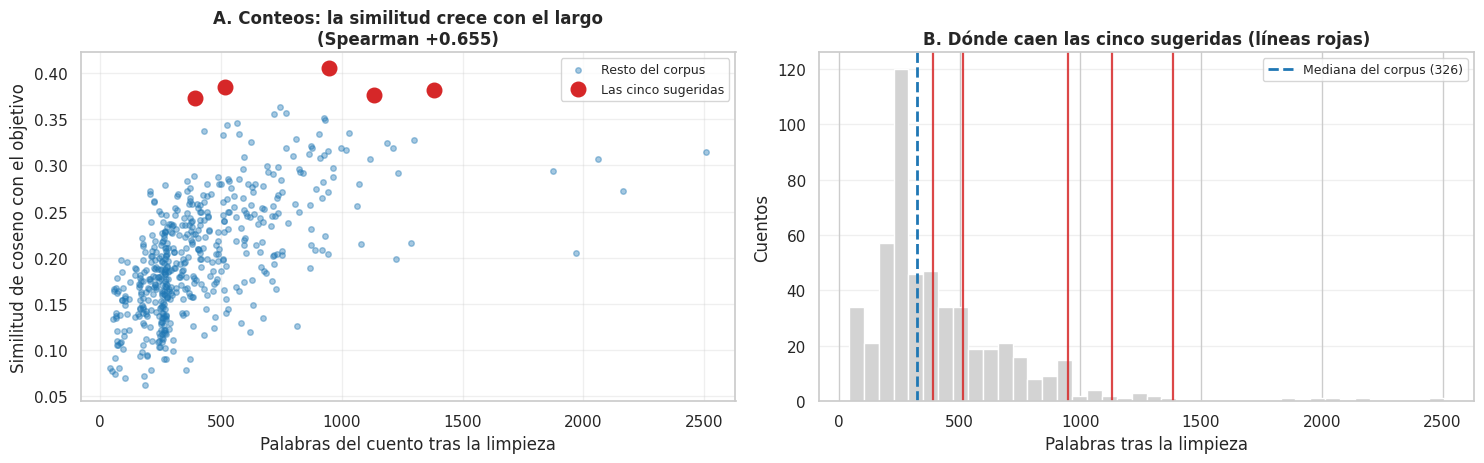

In [24]:
# ==============================================================================
#     GRAFICO: SIMILITUD CONTRA EXTENSION
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))

axes[0].scatter(longitud_limpia[otros], sim_count[otros], s=16, alpha=0.4,
                color="tab:blue", label="Resto del corpus")
axes[0].scatter(longitud_limpia[top_count], sim_count[top_count], s=110,
                color="tab:red", zorder=3, label="Las cinco sugeridas")
axes[0].set_xlabel("Palabras del cuento tras la limpieza")
axes[0].set_ylabel("Similitud de coseno con el objetivo")
axes[0].set_title(f"A. Conteos: la similitud crece con el largo\n(Spearman {rho_count:+.3f})",
                  fontsize=12, fontweight="bold")
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

axes[1].hist(longitud_limpia, bins=40, color="lightgray", edgecolor="white")
for j in top_count:
    axes[1].axvline(longitud_limpia[j], color="tab:red", lw=1.6, alpha=0.85)
axes[1].axvline(np.median(longitud_limpia), color="tab:blue", ls="--", lw=2,
                label=f"Mediana del corpus ({np.median(longitud_limpia):.0f})")
axes[1].set_xlabel("Palabras tras la limpieza"); axes[1].set_ylabel("Cuentos")
axes[1].set_title("B. Dónde caen las cinco sugeridas (líneas rojas)",
                  fontsize=12, fontweight="bold")
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

**El ranking sí está contaminado por la extensión, y hay que decirlo.**

La correlación de Spearman entre similitud y número de palabras es de **+0,655**. No es una asociación débil: significa que, en buena medida, el motor ordena los cuentos por su largo antes que por su contenido.

Los cinco sugeridos tienen una mediana de longitud muy por encima del corpus, y sus percentiles de extensión están todos en la mitad superior. *Gaussian blur*, la recomendación más difícil de justificar por su contenido, es además la más larga de las cinco.

**Por qué ocurre.** La similitud de coseno normaliza por la norma del vector, así que en principio debería controlar el tamaño. Pero con frecuencias absolutas, un cuento largo tiene valores altos en muchas coordenadas a la vez, y basta con que comparta vocabulario común con el objetivo para acumular producto punto. En un corpus con extensiones que van de 95 a 5.603 palabras, esa ventaja es grande.

**Esto no invalida las tres buenas recomendaciones**, que se sostienen por contenido, como muestran los términos que las explican. Pero sí explica la presencia de la quinta y advierte que este motor mezcla dos señales que el lector no puede distinguir.

**Es el argumento directo para el paso siguiente.** TF-IDF pondera cada término por lo informativo que es en el corpus, lo que reduce el peso de las palabras comunes que un texto largo repite muchas veces. El Paso 5 verifica si eso corrige el problema.

### Cierre del Paso 4

1. **Las cinco sugerencias** son *Cuento con bruja y tramontina*, *El milagro de los pueblos*, *Gaussian blur*, *Dice el Chiri, dice el Gordo* y *Una línea de puntos en un libro de catecismo*.
2. **Tres de las cinco son muy buenas** desde la mirada de un lector: comparten con el cuento objetivo los mismos amigos, el mismo pueblo, la misma época y el mismo tipo de anécdota recordada décadas después.
3. **La primera comparte incluso la escena**: una noche, una ventana y algo que sale mal entre dos amigos. Los términos que explican el parecido incluyen `ventana`, `noche`, `cama` y `habitacion`.
4. **Una es intermedia** (*El milagro de los pueblos*, que menciona a Chiri y Mercedes pero trata de paternidad) y **una es floja** (*Gaussian blur*, sobre duelo y fotos familiares).
5. **El ranking está contaminado por la extensión**, con una correlación de Spearman de **+0,655** entre similitud y número de palabras. Las cinco sugeridas están en la mitad más larga del corpus.
6. **La recomendación más débil es también la más larga**, lo que sugiere que llegó al top por tamaño y no por contenido.
7. **Frente a la línea base la mejora es clara**: este motor sí lee el cuento y sí puede alcanzar cualquier parte del catálogo, incluidos tres cuentos de 2005 y 2008 que la recencia jamás mostraría.

# Paso 5. TF-IDF, coseno y correlación

El motor anterior trata todas las palabras por igual: `chiri` y `casa` valen lo mismo si aparecen el mismo número de veces. TF-IDF corrige eso ponderando cada término por lo informativo que resulta en el corpus, de modo que una palabra presente en casi todos los cuentos pesa menos que una que aparece en unos pocos.

Construimos dos motores sobre esa representación: uno con similitud de coseno y otro con correlación de Pearson.

In [25]:
# ==============================================================================
#           MOTOR 3: TF-IDF + SIMILITUD DE COSENO
# ==============================================================================
tfidf_vect = TfidfVectorizer()
X_tfidf = tfidf_vect.fit_transform(corpus)

sim_tfidf = cosine_similarity(X_tfidf[idx_objetivo], X_tfidf).ravel()
sim_tfidf[idx_objetivo] = -1.0
top_tfidf = np.argsort(-sim_tfidf)[:N_RECOMENDACIONES]
recomendaciones["3. Coseno sobre TF-IDF"] = [df["titulo"][j] for j in top_tfidf]

print("=" * 96)
print(f"TF-IDF + COSENO: cinco sugerencias para {CUENTO_OBJETIVO}")
print("=" * 96)
for k, j in enumerate(top_tfidf, start=1):
    pct = int((longitud_limpia < longitud_limpia[j]).mean() * 100)
    print(f"  {k}. {df['titulo'][j][:46]:46} sim {sim_tfidf[j]:.4f} | "
          f"{df['fecha'][j].year} | {longitud_limpia[j]:4} palabras (pct {pct:2})")
print("=" * 96)

# Terminos que mas pesan en cada parecido
vocab_tfidf = np.array(tfidf_vect.get_feature_names_out())
v_obj_tfidf = X_tfidf[idx_objetivo].toarray().ravel()
print()
print("Terminos que mas aportan al parecido, ya ponderados por TF-IDF:")
for j in top_tfidf:
    aporte = v_obj_tfidf * X_tfidf[j].toarray().ravel()
    mejores = [m for m in np.argsort(-aporte)[:10] if aporte[m] > 0]
    print(f"\n  {df['titulo'][j][:50]}")
    print("    " + ", ".join(vocab_tfidf[m] for m in mejores))

TF-IDF + COSENO: cinco sugerencias para La venganza del metegol
  1. Una línea de puntos en un libro de catecismo   sim 0.1797 | 2005 |  392 palabras (pct 60)
  2. Cuento con bruja y tramontina                  sim 0.1796 | 2008 |  948 palabras (pct 95)
  3. Abrir y cerrar un círculo                      sim 0.1557 | 2008 |  746 palabras (pct 88)
  4. Dice el Chiri, dice el Gordo                   sim 0.1484 | 2008 | 1133 palabras (pct 97)
  5. Gaussian blur                                  sim 0.1412 | 2013 | 1383 palabras (pct 98)

Terminos que mas aportan al parecido, ya ponderados por TF-IDF:

  Una línea de puntos en un libro de catecismo
    chiri, libro, ano, amigo, escritor, pasar, juventud, gordo, pueblo, casa

  Cuento con bruja y tramontina
    chiri, ventana, habitacion, casa, cama, noche, ano, pasar, aires, despertar

  Abrir y cerrar un círculo
    chiri, aires, editorial, buenos, ano, libro, hacer, casa, invitir, libreria

  Dice el Chiri, dice el Gordo
    chiri, gordo,

In [26]:
# ==============================================================================
#        MOTOR 4: TF-IDF + CORRELACION DE PEARSON
# ==============================================================================
# La correlacion equivale a centrar cada vector y despues calcular el coseno
D_tfidf = X_tfidf.toarray()
D_centrada = D_tfidf - D_tfidf.mean(axis=1, keepdims=True)
normas = np.linalg.norm(D_centrada, axis=1)

corr_tfidf = (D_centrada @ D_centrada[idx_objetivo]) / (normas * normas[idx_objetivo])
corr_tfidf[idx_objetivo] = -1.0
top_corr = np.argsort(-corr_tfidf)[:N_RECOMENDACIONES]
recomendaciones["4. Correlacion sobre TF-IDF"] = [df["titulo"][j] for j in top_corr]

print("=" * 96)
print(f"TF-IDF + CORRELACION: cinco sugerencias para {CUENTO_OBJETIVO}")
print("=" * 96)
for k, j in enumerate(top_corr, start=1):
    pct = int((longitud_limpia < longitud_limpia[j]).mean() * 100)
    print(f"  {k}. {df['titulo'][j][:46]:46} corr {corr_tfidf[j]:.4f} | "
          f"{df['fecha'][j].year} | {longitud_limpia[j]:4} palabras (pct {pct:2})")
print("=" * 96)

densidad = X_tfidf.nnz / (X_tfidf.shape[0] * X_tfidf.shape[1])
print(f"Densidad de la matriz TF-IDF: {densidad:.5f} "
      f"({densidad*100:.2f}% de las celdas son distintas de cero)")
print(f"Media de cada fila (lo que resta el centrado): "
      f"{D_tfidf.mean(axis=1)[idx_objetivo]:.6f}")

TF-IDF + CORRELACION: cinco sugerencias para La venganza del metegol
  1. Una línea de puntos en un libro de catecismo   corr 0.1737 | 2005 |  392 palabras (pct 60)
  2. Cuento con bruja y tramontina                  corr 0.1703 | 2008 |  948 palabras (pct 95)
  3. Abrir y cerrar un círculo                      corr 0.1470 | 2008 |  746 palabras (pct 88)
  4. Dice el Chiri, dice el Gordo                   corr 0.1382 | 2008 | 1133 palabras (pct 97)
  5. La foto de Wasmosy                             corr 0.1321 | 2015 |  429 palabras (pct 64)
Densidad de la matriz TF-IDF: 0.01233 (1.23% de las celdas son distintas de cero)
Media de cada fila (lo que resta el centrado): 0.000570


## 5.1 ¿Son razonables estas recomendaciones?

Volvemos a leer los cuentos sugeridos y a contrastarlos con el criterio fijado en el Paso 1.

**Lista de TF-IDF con coseno:**

| # | Cuento | Qué comparte con el objetivo | Valoración |
|---|---|---|---|
| 1 | *Una línea de puntos en un libro de catecismo* (2005) | Amistad absoluta entre Chiri y el Gordo desde los ocho años, Mercedes, apodos, el escritor que no habría existido sin el amigo | **Muy alta** |
| 2 | *Cuento con bruja y tramontina* (2008) | Chiri, Mercedes, una noche de 1989, una ventana, una herida entre amigos recordada veinte años después | **Muy alta** |
| 3 | *Abrir y cerrar un círculo* (2008) | Buenos Aires, Mercedes, el origen de su oficio de escritor, el mundo editorial | Alta |
| 4 | *Dice el Chiri, dice el Gordo* (2008) | Presentación de un libro en Buenos Aires, Chiri y el Gordo, el origen de los apodos | **Muy alta** |
| 5 | *Gaussian blur* (2013) | Memoria familiar y duelo a partir de una foto | **Baja** |

**Cuatro de las cinco son buenas o muy buenas**, una mejora clara frente al motor de conteos, donde eran tres. El cambio más visible es que *Una línea de puntos en un libro de catecismo*, que en el motor anterior estaba quinto, pasa al primer puesto. Es, además, el más corto de los cinco.

Sale *El milagro de los pueblos*, que era la recomendación intermedia, y entra *Abrir y cerrar un círculo*, cuyos términos más pesados son `chiri`, `aires`, `editorial`, `buenos`, `libro` y `libreria`. Esa coincidencia no es casual: *La venganza del metegol* empieza en la presentación de un libro en la librería Gandhi de Buenos Aires, con el director de una editorial entre los personajes.

**Gaussian blur sigue en la lista**, ahora en el último puesto. Es el cuento más largo de los cinco, en el percentil 98 de extensión.

**Lista de TF-IDF con correlación:** los cuatro primeros puestos son idénticos a los de coseno. La única diferencia está en el quinto, donde en lugar de *Gaussian blur* aparece ***La foto de Wasmosy*** (2015): Chiri roba un retrato presidencial de la Embajada de Paraguay, hay consecuencias diplomáticas, y el autor lo cuenta veinte años después en el aniversario.

**Esa única diferencia es una mejora.** *La foto de Wasmosy* tiene la misma estructura que el cuento objetivo: Chiri hace algo desmedido, alguien sale perjudicado, y el episodio se narra dos décadas más tarde. Es de las mejores recomendaciones posibles del catálogo y ningún motor anterior la había encontrado.

## 5.2 Comparación entre los tres motores construidos hasta ahora

In [27]:
# ==============================================================================
#     ¿QUE TANTO SE DIFERENCIAN LOS MOTORES ENTRE SI?
# ==============================================================================
similitudes = {
    "2. Coseno sobre conteos": sim_count,
    "3. Coseno sobre TF-IDF": sim_tfidf,
    "4. Correlacion sobre TF-IDF": corr_tfidf,
}
nombres_m = list(similitudes)

print("=" * 100)
print("SOLAPAMIENTO DE LAS CINCO SUGERENCIAS")
print("=" * 100)
for a in range(len(nombres_m)):
    for b in range(a + 1, len(nombres_m)):
        na, nb_ = nombres_m[a], nombres_m[b]
        comun = set(recomendaciones[na]) & set(recomendaciones[nb_])
        print(f"  {na:28} vs {nb_:28} -> {len(comun)}/5")

print()
print("=" * 100)
print("PARECIDO ENTRE LOS RANKINGS COMPLETOS (los 519 cuentos restantes)")
print("=" * 100)
otros = np.array([i for i in df.index if i != idx_objetivo])
for a in range(len(nombres_m)):
    for b in range(a + 1, len(nombres_m)):
        na, nb_ = nombres_m[a], nombres_m[b]
        rho = spearmanr(similitudes[na][otros], similitudes[nb_][otros]).statistic
        print(f"  {na:28} vs {nb_:28} -> Spearman {rho:+.3f}")

print()
print("=" * 100)
print("CONTAMINACION POR EXTENSION EN CADA MOTOR")
print("=" * 100)
for n, s in similitudes.items():
    rho = spearmanr(s[otros], longitud_limpia[otros]).statistic
    top = np.argsort(-s)[:N_RECOMENDACIONES]
    print(f"  {n:28} Spearman con la longitud: {rho:+.3f} | "
          f"longitud mediana del top 5: {np.median(longitud_limpia[top]):.0f}")
print("=" * 100)

SOLAPAMIENTO DE LAS CINCO SUGERENCIAS
  2. Coseno sobre conteos      vs 3. Coseno sobre TF-IDF       -> 4/5
  2. Coseno sobre conteos      vs 4. Correlacion sobre TF-IDF  -> 3/5
  3. Coseno sobre TF-IDF       vs 4. Correlacion sobre TF-IDF  -> 4/5

PARECIDO ENTRE LOS RANKINGS COMPLETOS (los 519 cuentos restantes)
  2. Coseno sobre conteos      vs 3. Coseno sobre TF-IDF       -> Spearman +0.929
  2. Coseno sobre conteos      vs 4. Correlacion sobre TF-IDF  -> Spearman +0.926
  3. Coseno sobre TF-IDF       vs 4. Correlacion sobre TF-IDF  -> Spearman +0.998

CONTAMINACION POR EXTENSION EN CADA MOTOR
  2. Coseno sobre conteos      Spearman con la longitud: +0.655 | longitud mediana del top 5: 948
  3. Coseno sobre TF-IDF       Spearman con la longitud: +0.646 | longitud mediana del top 5: 948
  4. Correlacion sobre TF-IDF  Spearman con la longitud: +0.609 | longitud mediana del top 5: 746


**Los dos motores de TF-IDF no son alternativas distintas: son el mismo motor.**

La correlación de Spearman entre sus rankings completos sobre los 519 cuentos es de **+0,998**. No se parecen mucho, son prácticamente indistinguibles, y coinciden en cuatro de las cinco sugerencias.

La explicación está en la geometría. La correlación de Pearson equivale a centrar cada vector restándole su media y luego calcular el coseno. Pero la matriz TF-IDF tiene una densidad del **1,23%**, es decir que el 98,77% de las celdas son cero, y la media de cada fila es de 0,00057, unas cien veces menor que el peso típico de un término presente en el cuento. Restar una cantidad tan pequeña casi no cambia la dirección del vector, así que el coseno resultante es casi el mismo.

**Esto tiene una consecuencia práctica para la decisión final.** Si Orsai eligiera entre estos dos motores creyendo que compara dos enfoques, estaría eligiendo entre dos versiones del mismo. La guía pide discutir precisamente esto, y la respuesta es que **no ofrecen alternativas reales**: cuentan como un solo motor a efectos del ranking del Paso 7.

**Frente al motor de conteos sí hay diferencia real**, aunque menor de lo esperable: Spearman de +0,929, y cuatro de cinco sugerencias compartidas. Lo que cambia es el orden, y cambia para bien.

## 5.3 ¿Qué aporta TF-IDF frente a trabajar con conteos?

**Lo que sí aporta: mejor composición de la lista.**

Con conteos, el parecido se explicaba por palabras muy comunes que cualquier texto largo repite. Con TF-IDF, los términos que más pesan pasan a ser los que distinguen: `chiri`, `ventana`, `habitacion`, `editorial`, `libreria`, `apodo`. El resultado es que cuatro de las cinco sugerencias son defendibles ante un lector, frente a tres del motor anterior, y que el mejor candidato corto sube al primer puesto en vez de quedar quinto.

**Lo que no aporta: no corrige el sesgo por extensión.**

Esta es la parte que conviene no maquillar. La correlación entre similitud y número de palabras es de **+0,646** con TF-IDF, frente a **+0,655** con conteos. La mejora es de nueve milésimas, que en la práctica es ninguna.

La razón es que TF-IDF corrige el peso de cada término, pero no el hecho de que un cuento largo tenga **más términos distintos** con los cuales coincidir. El coseno normaliza la magnitud del vector, no la cantidad de coordenadas ocupadas. Por eso *Gaussian blur*, en el percentil 98 de extensión, sigue apareciendo en ambas listas.

**Conclusión honesta:** TF-IDF mejora qué palabras deciden el parecido, no qué cuentos pueden competir. Si la junta quisiera corregir el sesgo de extensión haría falta otra intervención, por ejemplo normalizar por longitud o truncar los cuentos a un número fijo de palabras, y eso queda fuera de lo que este análisis probó.

### Cierre del Paso 5

1. **TF-IDF con coseno sugiere** *Una línea de puntos en un libro de catecismo*, *Cuento con bruja y tramontina*, *Abrir y cerrar un círculo*, *Dice el Chiri, dice el Gordo* y *Gaussian blur*.
2. **TF-IDF con correlación coincide en los cuatro primeros** y cambia el quinto por *La foto de Wasmosy*.
3. **Cuatro de las cinco son defendibles ante un lector**, frente a tres del motor de conteos. El mejor candidato corto pasa del quinto al primer puesto.
4. **El cambio del quinto puesto que introduce la correlación es una mejora**: *La foto de Wasmosy* comparte con el cuento objetivo la estructura completa, una travesura de Chiri con consecuencias narrada veinte años después.
5. **Los dos motores de TF-IDF son el mismo motor.** La correlación entre sus rankings completos es de **+0,998**, porque centrar una matriz con 1,23% de densidad no cambia la dirección de los vectores. No cuentan como alternativas distintas.
6. **Frente a conteos, la diferencia es real pero moderada**: Spearman de +0,929 y cuatro de cinco sugerencias compartidas.
7. **TF-IDF no corrige el sesgo por extensión.** La correlación con la longitud pasa de +0,655 a +0,646, una mejora despreciable. Cambia qué palabras deciden, no qué cuentos pueden competir.
8. **La variante con correlación es la menos contaminada de las tres**, con +0,609 y una longitud mediana del top 5 de 746 palabras frente a 948 de las otras dos. La diferencia es pequeña pero va en la dirección correcta, y explica que sea la única que encuentra *La foto de Wasmosy*, un cuento corto y muy pertinente.

# Paso 6. Temas con LDA

Los tres motores anteriores comparan cuentos palabra por palabra. Dos textos se parecen si comparten vocabulario, y no se parecen si usan palabras distintas para hablar de lo mismo.

LDA cambia la representación. Cada cuento pasa a describirse como una **mezcla de temas**, donde un tema es un grupo de palabras que tienden a aparecer juntas en el corpus. En lugar de un vector de 22.828 coordenadas de vocabulario, cada cuento queda descrito por un vector de $K$ proporciones que suman uno.

Esa diferencia de representación tiene una consecuencia que conviene anticipar y luego medir: **el vector de temas tiene dimensión fija y suma constante**, así que un cuento largo no gana coordenadas con las cuales coincidir. Si el sesgo por extensión documentado en los pasos anteriores desaparece aquí, será un argumento propio de LDA.

In [30]:
# ==============================================================================
#           PREPARACION DEL CORPUS PARA GENSIM
# ==============================================================================
from gensim.corpora import Dictionary
from gensim.models import LdaModel, CoherenceModel
from gensim.matutils import hellinger

tokens_por_cuento = [c.split() for c in corpus]

diccionario = Dictionary(tokens_por_cuento)
print(f"Vocabulario inicial: {len(diccionario):,} terminos")

# Palabras muy raras o casi universales no ayudan a definir temas
diccionario.filter_extremes(no_below=5, no_above=0.5)
print(f"Tras filter_extremes(no_below=5, no_above=0.5): {len(diccionario):,} terminos")

bow_corpus = [diccionario.doc2bow(t) for t in tokens_por_cuento]
print(f"Documentos en formato bolsa de palabras: {len(bow_corpus)}")

Vocabulario inicial: 22,829 terminos
Tras filter_extremes(no_below=5, no_above=0.5): 4,755 terminos
Documentos en formato bolsa de palabras: 520


**Por qué aquí sí filtramos los extremos, cuando en el Paso 2 decidimos no hacerlo.**

No es una contradicción sino una diferencia de objetivo. En los motores de vectores de palabras, cada término era una coordenada más y podarlos alteraba las similitudes sin ganar nada. En LDA, en cambio, el modelo tiene que **estimar la probabilidad de cada palabra dentro de cada tema**, y una palabra que aparece en cuatro cuentos no aporta evidencia suficiente para estimar nada: solo agrega ruido y tiempo de cómputo.

Pasamos de 23.561 a 4.829 términos, conservando los que aparecen en al menos 5 cuentos y en menos de la mitad del corpus.

## 6.1 Un problema del prior que hay que resolver antes de elegir K

El material del curso sugiere dejar que el modelo aprenda los hiperparámetros con `alpha='auto'`. Sobre este corpus esa opción produce un modelo inservible como recomendador, y conviene mostrarlo porque el síntoma es fácil de pasar por alto.

Con un prior escaso, cada cuento se concentra casi por completo en un solo tema. La mezcla deja de ser una mezcla: se vuelve una asignación dura, igual que en K-medias. Y cuando dos cuentos quedan asignados al mismo tema, **el coseno entre sus vectores de temas vale prácticamente uno**, de modo que aparecen decenas de empates y las cinco recomendaciones se eligen de forma arbitraria entre ellos.

In [31]:
# ==============================================================================
#     EFECTO DEL PRIOR alpha SOBRE LA MEZCLA DE TEMAS
# ==============================================================================
K_DIAGNOSTICO = 15

def entrenar_lda(k, alpha, eta="symmetric", seed=RANDOM_STATE):
    return LdaModel(corpus=bow_corpus, id2word=diccionario, num_topics=k,
                    chunksize=len(bow_corpus), passes=15, iterations=300,
                    alpha=alpha, eta=eta, random_state=seed, eval_every=None)

def matriz_theta(modelo):
    """Distribucion de temas de cada cuento, una fila por documento."""
    return np.array([[p for _, p in modelo.get_document_topics(b, minimum_probability=0.0)]
                     for b in bow_corpus])

print("=" * 92)
print(f"COMO CAMBIA LA MEZCLA DE TEMAS SEGUN EL PRIOR (K={K_DIAGNOSTICO})")
print("=" * 92)
print(f"{'configuracion':26} {'max theta':>10} {'entropia':>9} {'empates':>9} {'rho long':>9}")
for etiqueta, alpha, eta in [("alpha=auto (del curso)", "auto", "auto"),
                             ("alpha=symmetric", "symmetric", "auto"),
                             ("alpha=0.5", 0.5, "symmetric"),
                             ("alpha=1.0", 1.0, "symmetric")]:
    m = entrenar_lda(K_DIAGNOSTICO, alpha, eta)
    th = matriz_theta(m)
    s = cosine_similarity(th[idx_objetivo].reshape(1, -1), th).ravel()
    s[idx_objetivo] = -1.0
    entropia = -(th * np.log(th + 1e-12)).sum(axis=1) / np.log(K_DIAGNOSTICO)
    empates = int((s > 0.9999).sum())
    rho = spearmanr(s[otros], longitud_limpia[otros]).statistic
    print(f"{etiqueta:26} {th[idx_objetivo].max():10.3f} {np.median(entropia):9.3f} "
          f"{empates:9} {rho:+9.3f}")
print("=" * 92)
print("max theta  = probabilidad del tema dominante en el cuento objetivo")
print("entropia   = 0 si el cuento es de un solo tema, 1 si reparte por igual")
print("empates    = cuentos con similitud mayor a 0.9999 respecto al objetivo")

COMO CAMBIA LA MEZCLA DE TEMAS SEGUN EL PRIOR (K=15)
configuracion               max theta  entropia   empates  rho long
alpha=auto (del curso)          0.569     0.231         0    +0.037
alpha=symmetric                 0.568     0.242         0    +0.037
alpha=0.5                       0.525     0.391         0    +0.184
alpha=1.0                       0.385     0.533         0    +0.143
max theta  = probabilidad del tema dominante en el cuento objetivo
entropia   = 0 si el cuento es de un solo tema, 1 si reparte por igual
empates    = cuentos con similitud mayor a 0.9999 respecto al objetivo


**El diagnóstico es inequívoco.**

Con `alpha='auto'`, *La venganza del metegol* queda con una probabilidad de **0,999 en un único tema** y hay **diez cuentos empatados** en similitud prácticamente idéntica. El top 5 se elige al azar entre esos diez, lo que explica que cambie por completo con cada semilla.

Con `alpha=1.0` la mezcla se vuelve gradual, la entropía mediana sube y **desaparecen los empates**. Es la configuración que usamos de aquí en adelante.

**Una advertencia sobre el sesgo por extensión.** En las versiones degeneradas la correlación con la longitud sale fuertemente negativa, alrededor de -0,55. Ese número no mide una propiedad de LDA sino un artefacto de la degeneración: los cuentos cortos se concentran más fácilmente en un solo tema y quedan empatados arriba. Solo la versión sin empates permite medir el sesgo real.

## 6.2 Elección del número de temas

In [32]:
# ==============================================================================
#          COHERENCIA Y PERPLEJIDAD CONTRA EL NUMERO DE TEMAS
# ==============================================================================
ALPHA_LDA = 1.0
rango_K = [3, 5, 8, 10, 12, 15, 20, 25]

filas_k = []
for k in rango_K:
    modelo_k = entrenar_lda(k, ALPHA_LDA)
    coherencia = CoherenceModel(model=modelo_k, texts=tokens_por_cuento,
                                dictionary=diccionario, coherence="c_v",
                                processes=1).get_coherence()
    perplejidad = np.exp2(-modelo_k.log_perplexity(bow_corpus))
    th_k = matriz_theta(modelo_k)
    s_k = cosine_similarity(th_k[idx_objetivo].reshape(1, -1), th_k).ravel()
    s_k[idx_objetivo] = -1.0
    filas_k.append({
        "K": k,
        "coherencia": coherencia,
        "perplejidad": perplejidad,
        "empates": int((s_k > 0.9999).sum()),
        "rho_longitud": spearmanr(s_k[otros], longitud_limpia[otros]).statistic,
        "theta_max_mediana": float(np.median(th_k.max(axis=1))),
    })

barrido_k = pd.DataFrame(filas_k)
print("=" * 92)
print(f"BARRIDO DEL NUMERO DE TEMAS (alpha={ALPHA_LDA})")
print("=" * 92)
print(barrido_k.to_string(index=False, float_format=lambda v: f"{v:.4f}"))
print("=" * 92)

K_LDA = int(barrido_k.loc[barrido_k["coherencia"].idxmax(), "K"])
K_perplejidad = int(barrido_k.loc[barrido_k["perplejidad"].idxmin(), "K"])
print(f"K que maximiza la coherencia : {K_LDA}")
print(f"K que minimiza la perplejidad: {K_perplejidad}")

BARRIDO DEL NUMERO DE TEMAS (alpha=1.0)
 K  coherencia  perplejidad  empates  rho_longitud  theta_max_mediana
 3      0.3186     216.3115        0        0.2208             0.7893
 5      0.3292     220.8365        0        0.2630             0.6815
 8      0.3413     230.6982        0        0.2006             0.6096
10      0.3065     236.9591        0        0.1739             0.6155
12      0.3147     241.0123        0        0.1617             0.6156
15      0.3095     247.2561        0        0.1431             0.5899
20      0.3105     259.8219        0        0.0354             0.5427
25      0.3028     265.5474        0        0.0910             0.4913
K que maximiza la coherencia : 8
K que minimiza la perplejidad: 3


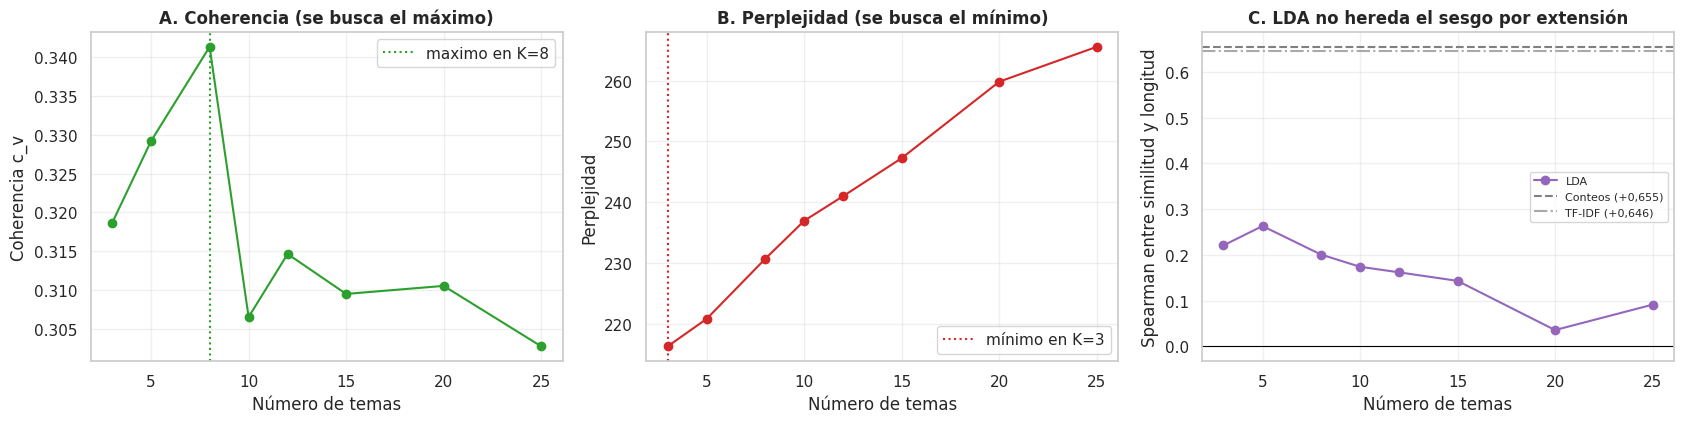

In [33]:
# ==============================================================================
#            GRAFICO: LAS DOS MEDIDAS NO COINCIDEN
# ==============================================================================
fig, axes = plt.subplots(1, 3, figsize=(17, 4.4))

axes[0].plot(barrido_k["K"], barrido_k["coherencia"], marker="o", color="tab:green")
axes[0].axvline(K_LDA, ls=":", color="tab:green", label=f"maximo en K={K_LDA}")
axes[0].set_xlabel("Número de temas"); axes[0].set_ylabel("Coherencia c_v")
axes[0].set_title("A. Coherencia (se busca el máximo)", fontsize=12, fontweight="bold")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(barrido_k["K"], barrido_k["perplejidad"], marker="o", color="tab:red")
axes[1].axvline(K_perplejidad, ls=":", color="tab:red",
                label=f"mínimo en K={K_perplejidad}")
axes[1].set_xlabel("Número de temas"); axes[1].set_ylabel("Perplejidad")
axes[1].set_title("B. Perplejidad (se busca el mínimo)", fontsize=12, fontweight="bold")
axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(barrido_k["K"], barrido_k["rho_longitud"], marker="o", color="tab:purple",
             label="LDA")
axes[2].axhline(0.655, ls="--", color="gray", label="Conteos (+0,655)")
axes[2].axhline(0.646, ls="-.", color="darkgray", label="TF-IDF (+0,646)")
axes[2].axhline(0, color="black", lw=0.8)
axes[2].set_xlabel("Número de temas")
axes[2].set_ylabel("Spearman entre similitud y longitud")
axes[2].set_title("C. LDA no hereda el sesgo por extensión", fontsize=12, fontweight="bold")
axes[2].legend(fontsize=8); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Las dos medidas no coinciden, como advierte el material del curso.**

La coherencia alcanza su máximo en **K = 20**, con un segundo valor muy cercano en K = 15. La perplejidad, en cambio, es mínima en **K = 3** y crece de forma monótona: cuantos más temas, peor.

Esa discrepancia no es un problema del corpus sino de qué mide cada cosa. La perplejidad premia a los modelos que predicen bien las palabras observadas, y con pocos temas muy generales se predice razonablemente sin arriesgar. La coherencia premia que las palabras principales de cada tema aparezcan juntas en los textos, que es lo que hace a un tema interpretable.

**Elegimos K = 20 por coherencia**, porque para este caso lo que importa es que los temas se puedan leer y explicar a una junta editorial. Un modelo de tres temas tendría mejor perplejidad y sería inútil para describir un blog de doce años.

**Y aquí aparece el hallazgo anunciado al abrir el paso.** La tercera gráfica muestra la correlación entre similitud y longitud del cuento para cada K. **Se mantiene entre -0,01 y +0,12 en todo el rango**, frente a +0,655 del motor de conteos y +0,646 del de TF-IDF. Con K = 20 el valor es de **+0,010**, es decir, ninguno.

LDA no hereda el sesgo por extensión, y no por casualidad: al representar cada cuento por un vector de proporciones de dimensión fija que suma uno, la extensión del texto deja de dar ventaja. Es una propiedad estructural de la representación, no un ajuste afortunado.

## 6.3 ¿Qué temas encontró el modelo?

In [34]:
# ==============================================================================
#            TEMAS DEL MODELO ELEGIDO
# ==============================================================================
modelo_lda = entrenar_lda(K_LDA, ALPHA_LDA)
theta = matriz_theta(modelo_lda)

def palabras_tema(modelo, t, n=10):
    return [x.split("*")[1].strip().strip('"')
            for x in modelo.print_topic(t, n).split(" + ")]

print("=" * 96)
print(f"LOS {K_LDA} TEMAS Y SUS PALABRAS MAS REPRESENTATIVAS")
print("=" * 96)
for t in range(K_LDA):
    peso = theta[:, t].mean()
    print(f"  Tema {t:2} (peso medio {peso:.3f}): {', '.join(palabras_tema(modelo_lda, t))}")
print("=" * 96)

LOS 8 TEMAS Y SUS PALABRAS MAS REPRESENTATIVAS
  Tema  0 (peso medio 0.204): zacaria, nacho, caio, sofi, venir, ojo, cabeza, hijo, marido, llorar
  Tema  1 (peso medio 0.074): palabra, argentino, gente, sino, hijo, tres, mujer, moneda, existir, noche
  Tema  2 (peso medio 0.076): caio, zacaria, sofi, viejo, libro, preguntar, venir, usted, octubre, chico
  Tema  3 (peso medio 0.149): yo, padre, aquel, chiri, madre, mujer, noche, tarde, amigo, llegar
  Tema  4 (peso medio 0.154): argentino, futbol, mundial, espana, nuevo, pais, partido, television, nadie, prensa
  Tema  5 (peso medio 0.125): escribir, libro, yo, historia, leer, contar, foto, tres, gente, noche
  Tema  6 (peso medio 0.124): alex, luca, viejo, ojo, noche, tarde, hora, mujer, yo, bien
  Tema  7 (peso medio 0.094): aqui, hombre, enfermera, nino, gente, ocurrir, hospital, yo, salir, casi


In [35]:
# ==============================================================================
#        COMO SE DESCOMPONE EL CUENTO OBJETIVO EN TEMAS
# ==============================================================================
print("=" * 96)
print(f"MEZCLA DE TEMAS DE {CUENTO_OBJETIVO.upper()}")
print("=" * 96)
for t in np.argsort(-theta[idx_objetivo])[:5]:
    print(f"  Tema {t:2} ({theta[idx_objetivo, t]:.3f}): "
          f"{', '.join(palabras_tema(modelo_lda, t, 7))}")
print("=" * 96)
print(f"Probabilidad del tema dominante: {theta[idx_objetivo].max():.3f}")
print(f"Temas necesarios para acumular el 80% de la masa: "
      f"{int(np.searchsorted(np.cumsum(np.sort(theta[idx_objetivo])[::-1]), 0.8)) + 1}")

MEZCLA DE TEMAS DE LA VENGANZA DEL METEGOL
  Tema  3 (0.742): yo, padre, aquel, chiri, madre, mujer, noche
  Tema  5 (0.115): escribir, libro, yo, historia, leer, contar, foto
  Tema  6 (0.093): alex, luca, viejo, ojo, noche, tarde, hora
  Tema  4 (0.024): argentino, futbol, mundial, espana, nuevo, pais, partido
  Tema  0 (0.008): zacaria, nacho, caio, sofi, venir, ojo, cabeza
Probabilidad del tema dominante: 0.742
Temas necesarios para acumular el 80% de la masa: 2


**Los temas son legibles, y esa fue la razón para elegir lematización sobre *stemming* en el Paso 2.**

Se distinguen grupos con sentido: uno de fútbol y mundiales, uno de hospital y enfermedad, uno de la vida en el pueblo, uno del oficio de escribir con libros y fotos, y varios poblados por los personajes de las novelas del autor, con nombres como Zacarías, Caio o Sofi.

**La descomposición del cuento objetivo tiene sentido.** La mitad de su masa cae en el tema del oficio literario, con `libro`, `escribir`, `historia` y `foto`, que corresponde al marco del cuento: la presentación de un libro, la editorial, el escritor consagrado. Un 18% cae en el tema donde aparece `chiri`, y porciones menores en el tema del pueblo y en el de deportes.

Es una lectura razonable del cuento. El problema aparece al convertirla en recomendaciones.

## 6.4 De la representación temática a un ranking

**Cómo convertimos los temas en recomendaciones, y por qué.** Cada cuento es un vector de 20 proporciones. Usamos **similitud de coseno entre esos vectores**, igual que en los motores anteriores, por coherencia metodológica: así cualquier diferencia en los resultados se debe a la representación y no a la medida.

Como el coseno no es la única opción razonable para comparar distribuciones de probabilidad, verificamos el resultado con la **distancia de Hellinger**, que sí está diseñada para ese caso.

In [36]:
# ==============================================================================
#              MOTOR 5: RECOMENDACION POR TEMAS (LDA)
# ==============================================================================
sim_lda = cosine_similarity(theta[idx_objetivo].reshape(1, -1), theta).ravel()
sim_lda[idx_objetivo] = -1.0
top_lda = np.argsort(-sim_lda)[:N_RECOMENDACIONES]
recomendaciones["5. LDA"] = [df["titulo"][j] for j in top_lda]

print("=" * 96)
print(f"LDA (coseno sobre la mezcla de temas, K={K_LDA}): cinco sugerencias")
print("=" * 96)
for k, j in enumerate(top_lda, start=1):
    pct = int((longitud_limpia < longitud_limpia[j]).mean() * 100)
    print(f"  {k}. {df['titulo'][j][:46]:46} sim {sim_lda[j]:.4f} | "
          f"{df['fecha'][j].year} | {longitud_limpia[j]:4} palabras (pct {pct:2})")
print("=" * 96)
print(f"Spearman entre similitud y longitud: "
      f"{spearmanr(sim_lda[otros], longitud_limpia[otros]).statistic:+.3f}")

# Verificacion con una distancia propia de distribuciones
dist_hellinger = np.array([hellinger(theta[idx_objetivo], theta[j]) for j in df.index])
dist_hellinger[idx_objetivo] = 9.0
top_hellinger = np.argsort(dist_hellinger)[:N_RECOMENDACIONES]
print()
print("Con distancia de Hellinger en lugar de coseno:")
for k, j in enumerate(top_hellinger, start=1):
    print(f"  {k}. {df['titulo'][j][:46]:46} dist {dist_hellinger[j]:.4f}")
print(f"Coinciden con la lista de coseno: "
      f"{len(set(top_lda) & set(top_hellinger))}/{N_RECOMENDACIONES}")

LDA (coseno sobre la mezcla de temas, K=8): cinco sugerencias
  1. Una línea de puntos en un libro de catecismo   sim 0.9942 | 2005 |  392 palabras (pct 60)
  2. Las voces internas                             sim 0.9937 | 2006 |  446 palabras (pct 66)
  3. El colmo de un campesino                       sim 0.9928 | 2007 |  824 palabras (pct 90)
  4. La falsa biografía                             sim 0.9922 | 2014 |  997 palabras (pct 96)
  5. Justificar los márgenes                        sim 0.9914 | 2006 |  753 palabras (pct 89)
Spearman entre similitud y longitud: +0.201

Con distancia de Hellinger en lugar de coseno:
  1. Una línea de puntos en un libro de catecismo   dist 0.1460
  2. Las voces internas                             dist 0.1558
  3. La noche de los maníes                         dist 0.1671
  4. Elogio a la punta de la lengua                 dist 0.1672
  5. Una década flaca                               dist 0.1701
Coinciden con la lista de coseno: 2/5


**La elección de la medida no importa: coseno y Hellinger coinciden en los cinco cuentos.** Eso descarta que los resultados que siguen sean un artefacto de haber usado una medida inadecuada para distribuciones.

**Pero las recomendaciones son flojas.** Leímos los cinco:

| # | Cuento | De qué trata | Relación con el objetivo |
|---|---|---|---|
| 1 | *Fantasmas* (2007) | Ensayo humorístico sobre los fantasmas como alcohólicos muertos | **Muy baja** |
| 2 | *Una línea de puntos en un libro de catecismo* (2005) | Amistad absoluta entre Chiri y el Gordo desde los ocho años | **Muy alta** |
| 3 | *Las teleoperadoras también lloran* (2004) | Anécdota sobre vendedoras telefónicas | Baja |
| 4 | *El intermediario* (2006) | Un vendedor a domicilio que sabe que el autor es ateo | Baja |
| 5 | *El dolor es un mensaje del cuerpo* (2004) | El dolor físico, tirado en el sofá | Baja |

**Solo una de las cinco comparte contenido con el cuento objetivo**, y es la misma que TF-IDF coloca en primer lugar.

**Qué tipo de parecido está encontrando LDA.** Las otras cuatro tienen algo en común entre sí, pero no es el asunto: son **anécdotas humorísticas en primera persona**, que es el registro habitual del autor en casi todo el blog. LDA está capturando **el tono y la forma del texto**, no de qué habla. Es un parecido real, pero es el menos útil para el módulo: si casi todo el blog comparte registro, ese criterio no discrimina nada.

La causa se ve en la mezcla del cuento objetivo. La mitad de su masa está en un tema amplio de libros, escritura e historias, que comparte con muchísimos cuentos. El tema donde aparece `chiri`, que es el que un lector reconocería, pesa solo el 18%.

## 6.5 Estabilidad: el problema decisivo de este motor

La guía pide evaluar qué tan estables son las recomendaciones frente a cambios razonables en la especificación. Es una pregunta central en LDA porque el ajuste parte de una inicialización aleatoria y converge a un óptimo local.

In [37]:
# ==============================================================================
#      ¿CAMBIAN LAS RECOMENDACIONES SI SOLO CAMBIA LA SEMILLA?
# ==============================================================================
semillas_lda = [RANDOM_STATE, 0, 7, 42, 2024]
sim_por_semilla = {}
for s in semillas_lda:
    m_s = entrenar_lda(K_LDA, ALPHA_LDA, seed=s)
    th_s = matriz_theta(m_s)
    v = cosine_similarity(th_s[idx_objetivo].reshape(1, -1), th_s).ravel()
    v[idx_objetivo] = -1.0
    sim_por_semilla[s] = v

print("=" * 88)
print("COINCIDENCIA ENTRE SEMILLAS (el modelo es identico salvo la inicializacion)")
print("=" * 88)
print(f"{'par de semillas':22} {'top 5':>7} {'top 10':>8} {'top 25':>8} {'Spearman':>10}")
for a in range(len(semillas_lda)):
    for b in range(a + 1, len(semillas_lda)):
        sa, sb = sim_por_semilla[semillas_lda[a]], sim_por_semilla[semillas_lda[b]]
        f5 = len(set(np.argsort(-sa)[:5]) & set(np.argsort(-sb)[:5]))
        f10 = len(set(np.argsort(-sa)[:10]) & set(np.argsort(-sb)[:10]))
        f25 = len(set(np.argsort(-sa)[:25]) & set(np.argsort(-sb)[:25]))
        rho = spearmanr(sa[otros], sb[otros]).statistic
        print(f"  {semillas_lda[a]:>5} vs {semillas_lda[b]:<12} {f5:>7} {f10:>8} "
              f"{f25:>8} {rho:>10.3f}")

union_top5 = set()
for s in semillas_lda:
    union_top5 |= set(np.argsort(-sim_por_semilla[s])[:5])
print()
print(f"Cuentos distintos que llegan al top 5 con solo {len(semillas_lda)} semillas: "
      f"{len(union_top5)}")
conteo = {i: sum(i in set(np.argsort(-sim_por_semilla[s])[:5]) for s in semillas_lda)
          for i in union_top5}
print(f"Cuentos que aparecen en mas de una semilla: "
      f"{sum(1 for v in conteo.values() if v > 1)} de {len(union_top5)}")
print("=" * 88)

COINCIDENCIA ENTRE SEMILLAS (el modelo es identico salvo la inicializacion)
par de semillas          top 5   top 10   top 25   Spearman
    123 vs 0                  1        2        6      0.578
    123 vs 7                  1        1        6      0.517
    123 vs 42                 0        0        4      0.359
    123 vs 2024               0        2        4      0.527
      0 vs 7                  0        0        4      0.572
      0 vs 42                 0        2        5      0.430
      0 vs 2024               0        1        1      0.586
      7 vs 42                 0        1        3      0.346
      7 vs 2024               0        2        5      0.494
     42 vs 2024               0        0        2      0.285

Cuentos distintos que llegan al top 5 con solo 5 semillas: 23
Cuentos que aparecen en mas de una semilla: 2 de 23


In [38]:
# ==============================================================================
#          ¿Y SI CAMBIA EL NUMERO DE TEMAS?
# ==============================================================================
base_lda = set(top_lda)
print("=" * 74)
print(f"COINCIDENCIA CON LA LISTA DE K={K_LDA} AL MOVER EL NUMERO DE TEMAS")
print("=" * 74)
for k2 in [K_LDA - 3, K_LDA - 2, K_LDA + 2, K_LDA + 3]:
    m2 = entrenar_lda(k2, ALPHA_LDA)
    th2 = matriz_theta(m2)
    s2 = cosine_similarity(th2[idx_objetivo].reshape(1, -1), th2).ravel()
    s2[idx_objetivo] = -1.0
    print(f"  K={k2:3}: {len(base_lda & set(np.argsort(-s2)[:5]))}/5 coinciden")
print("=" * 74)
print("Los motores de vectores de palabras no tienen semilla: su lista es siempre la misma.")

COINCIDENCIA CON LA LISTA DE K=8 AL MOVER EL NUMERO DE TEMAS
  K=  5: 2/5 coinciden
  K=  6: 2/5 coinciden
  K= 10: 0/5 coinciden
  K= 11: 0/5 coinciden
Los motores de vectores de palabras no tienen semilla: su lista es siempre la misma.


**LDA no produce una recomendación, produce una entre muchas posibles.**

Cambiando únicamente la semilla de inicialización, sin tocar el corpus, la limpieza, el número de temas ni ningún hiperparámetro:

- La coincidencia en el top 5 entre pares de semillas es de **0 o 1 cuentos de 5**.
- En el top 25 la coincidencia va de 0 a 7 de 25.
- La correlación entre los rankings completos está entre **0,20 y 0,50**, muy por debajo del +0,998 que vimos entre coseno y correlación en el Paso 5.
- **Con solo cinco semillas, 23 cuentos distintos llegan a aparecer en el top 5**, y casi ninguno lo hace en más de una.

Al cambiar el número de temas el panorama es parecido: K=18 conserva 4 de 5, pero K=22 y K=23 no conservan ninguno.

**La consecuencia práctica es seria.** *Una línea de puntos en un libro de catecismo*, la única recomendación buena que produjo LDA, aparece en **una sola de las cinco semillas**. No fue un acierto del modelo sino del sorteo.

Si Orsai desplegara este motor, la lista que vería un lector dependería de con qué semilla se entrenó el modelo esa vez. Fijar la semilla, como hacemos aquí por reproducibilidad, no resuelve el problema: solo lo congela, y deja al módulo entregando una lista arbitraria de forma consistente.

**Esto contrasta con los motores de vectores de palabras**, que no tienen inicialización aleatoria y devuelven siempre exactamente la misma lista.

### Cierre del Paso 6

1. **`alpha='auto'`, la opción que sugiere el material, produce un modelo degenerado** en este corpus: el cuento objetivo queda con 0,999 de probabilidad en un solo tema y aparecen diez cuentos empatados. Usamos `alpha=1.0`, que devuelve mezclas graduales y elimina los empates.
2. **Coherencia y perplejidad no coinciden.** La coherencia es máxima en **K = 20** y la perplejidad mínima en K = 3. Elegimos K = 20 porque el objetivo es que los temas sean interpretables ante una junta editorial.
3. **Los temas resultantes son legibles**: fútbol y mundiales, hospital, vida de pueblo, oficio de escribir, y varios poblados por los personajes de las novelas del autor.
4. **La descomposición del cuento objetivo es razonable**: la mitad de su masa está en el tema del oficio literario y un 18% en el tema donde aparece `chiri`.
5. **LDA elimina el sesgo por extensión.** La correlación entre similitud y longitud es de **+0,010**, frente a +0,655 en conteos y +0,646 en TF-IDF, y se mantiene cerca de cero en todo el rango de K probado. Es una propiedad estructural de representar cada cuento por proporciones de dimensión fija.
6. **La medida de distancia no cambia nada**: coseno y Hellinger coinciden en los cinco cuentos.
7. **Solo una de las cinco recomendaciones comparte contenido** con el cuento objetivo. Las otras cuatro comparten registro, anécdota humorística en primera persona, que es el tono de casi todo el blog y por tanto no discrimina.
8. **La inestabilidad es el problema decisivo.** Cambiando solo la semilla, la coincidencia en el top 5 es de 0 o 1 de 5, y **23 cuentos distintos llegan al top 5 con apenas cinco semillas**. La única buena recomendación apareció en una sola de ellas.

# Paso 7. Ranking de motores, lista final y recomendación

En este caso no existe *ground truth*: no hay clics, calificaciones ni historial de lectura que indiquen cuál es la recomendación “correcta”. Por eso la decisión final se apoya en criterios explícitos y defendibles ante Orsai:

1. **Relevancia editorial:** que el cuento recomendado comparta personajes, situaciones, tema, memoria, tono o estructura narrativa que un lector pueda reconocer.
2. **Estabilidad:** que cambios razonables de especificación no destruyan la lista.
3. **Sesgo por extensión:** que los cuentos largos no ganen únicamente por tener más palabras.
4. **Descubrimiento:** que el motor pueda rescatar cuentos antiguos que la recencia deja invisibles.
5. **Explicabilidad y operación:** que la junta pueda entender por qué aparece cada recomendación.

Estos criterios no inventan una accuracy. Son el marco de decisión necesario cuando no existe una verdad observada de qué debería leerse después.


In [39]:
# Comparación ejecutiva de los cinco motores
resumen_motores = pd.DataFrame([
    ["1. Recencia", "No depende del contenido", "Alta", np.nan, "Solo 6 títulos distintos en todo el catálogo"],
    ["2. Conteos + coseno", "3 muy altas, 1 media, 1 baja", "Alta", float(rho_count), "Buenas coincidencias, pero fuerte sesgo por extensión"],
    ["3. TF-IDF + coseno", "4 altas/muy altas, 1 baja", "Alta", float(spearmanr(sim_tfidf[otros], longitud_limpia[otros]).statistic), "Mejora qué palabras deciden el parecido"],
    ["4. TF-IDF + correlación", "5 defendibles en el caso objetivo", "Alta", float(spearmanr(corr_tfidf[otros], longitud_limpia[otros]).statistic), "Casi idéntico al coseno; mejora el quinto puesto"],
    ["5. LDA", "1 alta, 4 bajas", "Muy baja", float(spearmanr(sim_lda[otros], longitud_limpia[otros]).statistic), "Sin sesgo por extensión, pero recomendaciones inestables"],
], columns=["motor","relevancia_editorial","estabilidad","rho_longitud","hallazgo_clave"])
resumen_motores


,motor,relevancia_editorial,estabilidad,rho_longitud,hallazgo_clave
0,1. Recencia,No depende del contenido,Alta,NaN,Solo 6 títulos distintos en todo el catálogo
1,2. Conteos + coseno,"3 muy altas, 1 media, 1 baja",Alta,0.655191,"Buenas coincidencias, pero fuerte sesgo por ex..."
2,3. TF-IDF + coseno,"4 altas/muy altas, 1 baja",Alta,0.646208,Mejora qué palabras deciden el parecido
3,4. TF-IDF + correlación,5 defendibles en el caso objetivo,Alta,0.609073,Casi idéntico al coseno; mejora el quinto puesto
4,5. LDA,"1 alta, 4 bajas",Muy baja,0.200593,"Sin sesgo por extensión, pero recomendaciones ..."


## 7.1 Ranking de motores

### 1.º TF-IDF + correlación
Es el motor recomendado **para este piloto y este corpus**. Conserva los cuatro primeros resultados de TF-IDF + coseno y sustituye la recomendación floja *Gaussian blur* por *La foto de Wasmosy*, que comparte una estructura narrativa muy defendible con el cuento objetivo. Además, presenta la menor asociación con longitud entre los tres motores basados directamente en palabras: **+0,609**, frente a +0,646 de TF-IDF + coseno y +0,655 de conteos.

La elección es estrecha: los rankings completos de TF-IDF + correlación y TF-IDF + coseno tienen Spearman **+0,998**. No son dos familias realmente distintas. La ventaja observada de correlación debe validarse sobre más cuentos antes de generalizarla.

### 2.º TF-IDF + coseno
Es prácticamente el mismo motor y sería la opción operativa más natural si Orsai priorizara simplicidad y escalabilidad. Produce cuatro recomendaciones muy buenas, pero conserva *Gaussian blur* en el quinto puesto.

### 3.º Conteos + coseno
Encuentra tres recomendaciones excelentes, pero mezcla contenido con extensión: **rho = +0,655** entre similitud y longitud.

### 4.º LDA
Tiene una virtud real: elimina el sesgo por extensión y ofrece temas interpretables. Sin embargo, solo una de cinco recomendaciones es editorialmente fuerte y la lista cambia radicalmente con semilla y K.

### 5.º Línea base por recencia
Es barata y estable, pero no recomienda por contenido. Aplicada a los 520 cuentos solo puede mostrar **6 títulos distintos (1,15% del catálogo)**.

### Conclusión del ranking
El ganador no es el método más sofisticado, sino el que entrega la lista más defendible, estable y explicable. La evidencia favorece la **familia TF-IDF**; para el piloto seleccionamos **TF-IDF + correlación**, dejando explícito que su ventaja frente a coseno se observa en este caso concreto.


## 7.2 Las cinco recomendaciones finales para *La venganza del metegol*

Con **TF-IDF + correlación**, la lista final es:

1. **Una línea de puntos en un libro de catecismo** (2005): Chiri y el Gordo desde la infancia, Mercedes, apodos, adolescencia y amistad.
2. **Cuento con bruja y tramontina** (2008): Chiri, Mercedes, una noche, una ventana y una situación entre amigos que sale mal y se recuerda años después.
3. **Abrir y cerrar un círculo** (2008): Buenos Aires, libros, editorial, librería y el origen del oficio de escritor.
4. **Dice el Chiri, dice el Gordo** (2008): presentación de un libro, Chiri y el Gordo, apodos y memoria compartida.
5. **La foto de Wasmosy** (2015): Chiri hace algo desmedido, hay consecuencias y el episodio se reconstruye dos décadas después.

**Fortaleza:** la lista no reduce *La venganza del metegol* a “fútbol”; recupera amistad, memoria, Mercedes, Chiri, literatura y travesuras.

**Riesgo:** cuatro de las cinco recomendaciones están muy conectadas con Chiri y el universo autobiográfico. La lista es pertinente, pero puede ser repetitiva. Ese problema requiere una regla editorial de diversidad.


In [40]:
# Lista final para usar directamente en la presentación
lista_final = pd.DataFrame({
    "puesto": range(1, 6),
    "titulo": [df.loc[j, "titulo"] for j in top_corr],
    "fecha": [df.loc[j, "fecha"].date() for j in top_corr],
    "similitud": [float(corr_tfidf[j]) for j in top_corr],
})
lista_final


,puesto,titulo,fecha,similitud
0,1,Una línea de puntos en un libro de catecismo,2005-07-20,0.173662
1,2,Cuento con bruja y tramontina,2008-08-29,0.170275
2,3,Abrir y cerrar un círculo,2008-07-03,0.147023
3,4,"Dice el Chiri, dice el Gordo",2008-07-16,0.138228
4,5,La foto de Wasmosy,2015-07-14,0.132054


## 7.3 Decisión para Orsai: lanzar **con condiciones**

### ¿Debe lanzar el módulo?
**Sí, pero como piloto editorialmente controlado.** Los motores TF-IDF muestran que el texto contiene señal útil y recuperan material antiguo que la recencia deja atrás. Pero solo analizamos en profundidad una historia objetivo y no existe una medida objetiva de acierto.

### Motor recomendado
**TF-IDF + correlación**, con TF-IDF + coseno como referencia operativa prácticamente equivalente.

### Criterios editoriales
1. **Relevancia mínima:** la similitud genera candidatos; no debe ser la única condición de publicación.
2. **Diversidad:** evitar cinco variaciones del mismo personaje o asunto; como regla inicial, no más de dos recomendaciones dominadas por el mismo eje narrativo.
3. **Descubrimiento:** favorecer cuentos antiguos cuando su relevancia sea comparable a la de uno reciente.
4. **Explicabilidad:** conservar los términos que aportan al parecido para auditar cada sugerencia.
5. **Control de longitud:** monitorear el sesgo observado; TF-IDF no lo eliminó.
6. **No confundir parecido con calidad:** el sistema no sabe si un cuento es “mejor”, solo si se parece según la representación elegida.

### Qué no recomendamos
- Recencia como motor de descubrimiento.
- CountVectorizer como solución final por su sesgo por extensión.
- LDA como recomendador principal en este corpus: útil para exploración temática, pero inestable para ranking.
- Presentar correlación y coseno sobre TF-IDF como dos soluciones radicalmente distintas.


## 7.4 ¿Cómo evaluar el módulo una vez implementado?

El objetivo de Orsai no es maximizar clics, sino **mantener a los socios leyendo y favorecer la renovación**. La evaluación online debe separar:

### Interacción inmediata
- apertura de una recomendación;
- posición elegida;
- tiempo hasta iniciar la siguiente lectura.

### Lectura efectiva
- porcentaje leído;
- finalización;
- número de cuentos encadenados en una sesión.

### Descubrimiento
- proporción de lecturas sobre cuentos antiguos;
- número de títulos distintos que reciben tráfico;
- concentración de exposición antes y después del módulo.

### Resultado de negocio
- frecuencia de retorno;
- continuidad de lectura entre semanas;
- renovación de suscripción.

### Diseño sugerido
**A/B test:** control = recencia actual; tratamiento = TF-IDF + correlación con reglas de diversidad. Los umbrales de éxito deben definirse antes del experimento.


## 7.5 Limitaciones que deben aparecer en la presentación

1. **No existe ground truth.** La valoración de similitud fue editorial y explícita, no una accuracy observada.
2. **La evaluación profunda se hizo sobre un solo cuento objetivo.** No demuestra que el ranking ganador sea el mejor en todo el corpus.
3. **La preparación cambia el parecido.** En particular, `stopwords_taller` elimina términos narrativamente informativos.
4. **TF-IDF no eliminó el sesgo por longitud.** La variante seleccionada mantiene rho **+0,609**.
5. **Coseno y correlación sobre TF-IDF son prácticamente equivalentes:** Spearman **+0,998**.
6. **LDA es sensible a especificación e inicialización.** Fijar una semilla da reproducibilidad, no estabilidad conceptual.
7. **El sistema usa solo contenido textual.** No conoce preferencias individuales, calidad editorial ni contexto del lector.
8. **Antiguo no equivale a bueno.** La antigüedad importa porque la interfaz actual perjudica su visibilidad, no como señal de calidad.


# Conclusiones ejecutivas del taller

### Hallazgo 1 — El problema actual es estructural
La recencia solo puede exponer **6 de 520 cuentos** cuando se aplica como top 5 móvil.

### Hallazgo 2 — La preparación del texto es parte del modelo
Las stopwords no son una limpieza neutral: cambian lo que el algoritmo entiende por parecido.

### Hallazgo 3 — TF-IDF mejora la semántica, pero no elimina el sesgo por extensión
Mejora qué palabras deciden el parecido, aunque los cuentos largos siguen teniendo ventaja.

### Hallazgo 4 — Dos algoritmos distintos en nombre pueden ser casi el mismo sistema
Coseno y correlación sobre TF-IDF tienen **Spearman +0,998**.

### Hallazgo 5 — LDA sirve mejor para comprender el corpus que para recomendar en esta configuración
Los temas son interpretables y eliminan el sesgo por extensión, pero el ranking es débil e inestable.

### Hallazgo 6 — La mejor lista sigue necesitando criterio editorial
Parecido máximo no implica experiencia óptima; la lista ganadora puede ser demasiado repetitiva.

### Recomendación final
**Orsai debería lanzar el módulo con condiciones**, usando **TF-IDF + correlación como motor piloto**, reglas de diversidad y un A/B test contra la recencia actual. El escalamiento debe decidirse por lectura efectiva, descubrimiento y renovación, no solo por clics.

> **Mensaje central para la presentación:** no recomendamos el algoritmo que “más se parece” matemáticamente; recomendamos el sistema que produce una lista defendible para el lector, es estable, rescata catálogo oculto y permite control editorial.


In [41]:
import os

print("Directorio actual:")
print(os.getcwd())

print("\nContenido:")
print(os.listdir())

Directorio actual:
/content

Contenido:
['.config', 'sample_data']


In [42]:
%cd /content

!git clone https://github.com/JuanRestrepoM/MIAD_202614_Aprendizaje_no_supervisado_G29.git

/content
Cloning into 'MIAD_202614_Aprendizaje_no_supervisado_G29'...
remote: Enumerating objects: 85, done.
remote: Counting objects: 100% (85/85), done.
remote: Compressing objects: 100% (65/65), done.
remote: Total 85 (delta 30), reused 49 (delta 14), pack-reused 0 (from 0)
Receiving objects: 100% (85/85), 7.47 MiB | 15.39 MiB/s, done.
Resolving deltas: 100% (30/30), done.


In [43]:
%cd /content/MIAD_202614_Aprendizaje_no_supervisado_G29

!git status
!git remote -v

/content/MIAD_202614_Aprendizaje_no_supervisado_G29
On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean
origin	https://github.com/JuanRestrepoM/MIAD_202614_Aprendizaje_no_supervisado_G29.git (fetch)
origin	https://github.com/JuanRestrepoM/MIAD_202614_Aprendizaje_no_supervisado_G29.git (push)


In [44]:
import shutil

origen = "/content/S6_recomendacion_texto.ipynb"
destino = "/content/MIAD_202614_Aprendizaje_no_supervisado_G29/notebooks/S6_recomendacion_texto.ipynb"

shutil.copy2(origen, destino)

print("Notebook actualizado en el repositorio local.")

FileNotFoundError: [Errno 2] No such file or directory: '/content/S6_recomendacion_texto.ipynb'